## Introduction

Capstone Project:The business objective is to develop a predictive model that identifies diabetic patients at high risk of hospital readmission within 30 days of discharge. This model aims to enable healthcare providers to implement targeted interventions, improve patient outcomes, reduce healthcare costs associated with preventable readmissions, and optimize resource allocation.

# Capstone Project: Final Report

**Overview**: In this practical application, goal perform the Exploratory Data Analysis of data :Predicting Hospital Readmission within 30 Days : Diabetic patient readmissions within 30 days of discharge

Research data considered :
Predicting Hospital Readmission within 30 Days : Diabetic patient readmissions within 30 days of discharge represent a critical and costly issue for healthcare systems. These preventable readmissions significantly strain hospital resources, lead to substantial financial penalties, and most importantly, compromise patient well-being and recovery. Identifying patients at highest risk of readmission relies heavily on subjective assessments, leading to inefficient resource allocation and missed opportunities for timely intervention. This project leverages advanced machine learning techniques on a rich historical dataset of diabetic patient hospitalizations to develop a predictive model. This model will accurately identify patients at elevated risk of 30-day readmission upon discharge

Dataset Name: Diabetes 130-US hospitals for years 1999-2008 Data Set

Source: UCI Machine Learning Repository

Link : https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008Links to an external site.  



## Data Loading

### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008).  The data is from Hospital Readmission within 30 Days : Diabetic patient readmissions within 30 days of discharge represent a critical and costly issue for healthcare systems. These preventable readmissions significantly strain hospital resources, lead to substantial financial penalties, and most importantly, compromise patient well-being and recovery. Identifying patients at highest risk of readmission relies heavily on subjective assessments, leading to inefficient resource allocation and missed opportunities for timely intervention.


### Problem 1: Understanding the Data

Exploratory Data Analysis of Diabetic Readmissions Data
This section will perform Exploratory Data Analysis (EDA) on the 'Diabetic 130-US Hospitals for Years 1999-2008' dataset from the UCI Machine Learning Repository. The goal is to understand the dataset's structure, identify missing values, examine data distributions, and uncover potential patterns.

In [207]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [208]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import statsmodels
import statsmodels.api as sm

# URL to the data folder
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip'
zip_file_name = 'dataset_diabetes.zip'
data_file_name = 'diabetic_data.csv'

# Ensure the 'data' directory exists
if not os.path.exists('./data'):
    os.makedirs('./data')

# Download the zip file
!wget $data_url -O $zip_file_name

# Unzip the file into the 'data' directory
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('./data')

print("Data downloaded and extracted successfully into ./data")

--2026-06-04 15:00:48--  https://archive.ics.uci.edu/ml/machine-learning-databases/00296/dataset_diabetes.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘dataset_diabetes.zip’

dataset_diabetes.zi     [     <=>            ]   3.19M  2.67MB/s    in 1.2s    

2026-06-04 15:00:50 (2.67 MB/s) - ‘dataset_diabetes.zip’ saved [3347213]

Data downloaded and extracted successfully into ./data


In [209]:
df = pd.read_csv(os.path.join('./data', 'dataset_diabetes', data_file_name))

print(f"Dataset '{data_file_name}' loaded successfully. Shape: {df.shape}")

Dataset 'diabetic_data.csv' loaded successfully. Shape: (101766, 50)


In [210]:
print("Missing values after previous cleaning:")
display(df.isnull().sum()[df.isnull().sum() > 0])

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found in the DataFrame.")
else:
    print("\nSome columns still contain missing values.")

Missing values after previous cleaning:


,0
max_glu_serum,96420
A1Cresult,84748



Some columns still contain missing values.


### Problem 2: Read in the Data

Use pandas to read in the dataset  and assign to a meaningful variable name.

In [211]:
# Load the dataset with the corrected path
df = pd.read_csv(os.path.join('./data', 'dataset_diabetes', data_file_name))

print(f"Dataset '{data_file_name}' loaded successfully. Shape: {df.shape}")

Dataset 'diabetic_data.csv' loaded successfully. Shape: (101766, 50)


In [212]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Data Cleaning

### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

Now that the `diabetic_data.csv` has been loaded, let's understand its structure and content. We will look at column names, data types, non-null counts, and identify potential missing values, which are often represented by '?' in this dataset. We'll also examine descriptive statistics for numerical columns and unique values for categorical columns.

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Data Information and Missing Values
Next, we'll check the data types of each column and identify any missing values. According to the dataset description, '?' indicates missing values, so we'll treat them as such.

In [214]:
print("\nNumber of '?' values in each column:")
for column in df.columns:
    if (df[column] == '?').any():
        count = (df[column] == '?').sum()
        print(f"{column}: {count}")

# Count total '?' values across the entire DataFrame
total_missing_q_values = (df == '?').sum().sum()
print(f"\nTotal '?' values in the DataFrame: {total_missing_q_values}")


Number of '?' values in each column:
race: 2273
weight: 98569
payer_code: 40256
medical_specialty: 49949
diag_1: 21
diag_2: 358
diag_3: 1423

Total '?' values in the DataFrame: 192849


In [215]:
columns_to_drop = ['encounter_id', 'patient_nbr','payer_code','weight', 'medical_specialty']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print(f"Columns {columns_to_drop} dropped. New DataFrame shape: {df.shape}")

Columns ['encounter_id', 'patient_nbr', 'payer_code', 'weight', 'medical_specialty'] dropped. New DataFrame shape: (101766, 45)


In [216]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [217]:
# Display unique values and their counts for categorical columns
print("\nUnique values and their counts for categorical columns:")
for column in df.select_dtypes(include='object').columns:
    print(f"\n--- {column} ---")
    display(df[column].value_counts())


Unique values and their counts for categorical columns:

--- race ---


,count
race,
Caucasian,76099
AfricanAmerican,19210
?,2273
Hispanic,2037
Other,1506
Asian,641



--- gender ---


,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3



--- age ---


...

,count
change,
No,54755
Ch,47011



--- diabetesMed ---


,count
diabetesMed,
Yes,78363
No,23403



--- readmitted ---


,count
readmitted,
NO,54864
>30,35545
<30,11357


In [218]:
for column in ['diag_1', 'diag_2', 'diag_3']:
    # Replace '?' with numpy's NaN
    df[column] = df[column].replace('?', np.nan)

    # Get the mode of the column
    col_mode = df[column].mode()[0]

    # Impute missing values with the mode
    df[column] = df[column].fillna(col_mode)

    print(f"Missing '?' values in '{column}' column replaced with its mode: {col_mode}")
    print(f"New count of '?' in '{column}': {(df[column] == '?').sum()}\n")

# Verify no more '?' values exist in the DataFrame
total_missing_q_values = (df == '?').sum().sum()
print(f"Total '?' values remaining in the DataFrame: {total_missing_q_values}")

Missing '?' values in 'diag_1' column replaced with its mode: 428
New count of '?' in 'diag_1': 0

Missing '?' values in 'diag_2' column replaced with its mode: 276
New count of '?' in 'diag_2': 0

Missing '?' values in 'diag_3' column replaced with its mode: 250
New count of '?' in 'diag_3': 0

Total '?' values remaining in the DataFrame: 2273


In [219]:
# Replace '?' with numpy's NaN for easier handling of missing values
df['race'] = df['race'].replace('?', np.nan)

# Get the mode of the 'race' column
race_mode = df['race'].mode()[0]

# Impute missing 'race' values with the mode
df['race'] = df['race'].fillna(race_mode)

print(f"Missing '?' values in 'race' column replaced with its mode: {race_mode}")
print(f"New count of '?' in 'race': {(df['race'] == '?').sum()}")

Missing '?' values in 'race' column replaced with its mode: Caucasian
New count of '?' in 'race': 0


In [220]:
print("\nRemaining null values after '?' replacement:")
print(df[['max_glu_serum', 'A1Cresult']].isnull().sum())


Remaining null values after '?' replacement:
max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [221]:
# Fill NaN values in 'max_glu_serum' and 'A1Cresult' with 'None'
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['A1Cresult'].fillna('None')

print("Null values after filling:")
print(df[['max_glu_serum', 'A1Cresult']].isnull().sum())

Null values after filling:
max_glu_serum    0
A1Cresult        0
dtype: int64


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    101766 non-null  object
 14  diag

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [223]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Dropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"New DataFrame shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0


In [224]:
# Display data types to check for inconsistencies
print("\nDataFrame info after cleaning:")
df.info()


DataFrame info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  number_outpatient         101766 non-null  int64 
 11  number_emergency          101766 non-null  int64 
 12  number_inpatient          101766 non-null  int64 
 13  diag_1                    1

## Exploratory Data Analysis (EDA)

### Exploring Categorical Features

Let's begin by examining the distribution of the target variable, `readmitted`.

Distribution of 'readmitted' column:


,count
readmitted,
NO,54864
>30,35545
<30,11357


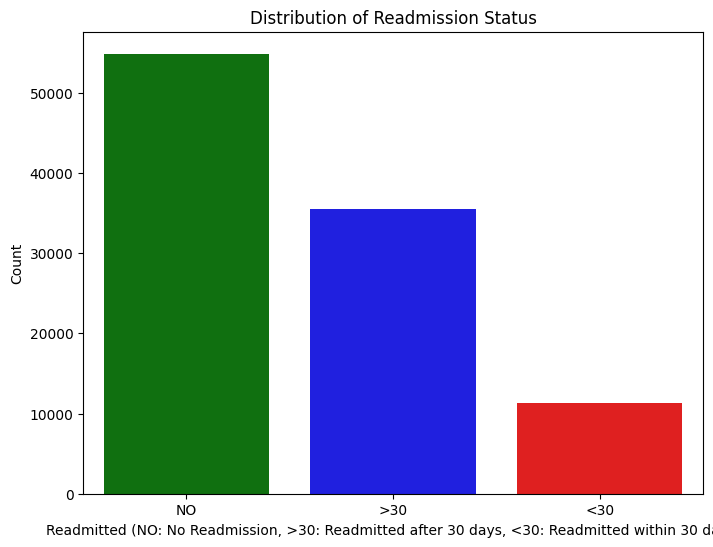

In [225]:
print("Distribution of 'readmitted' column:")
display(df['readmitted'].value_counts())

plt.figure(figsize=(8, 6))
# Define a custom palette: Red for '<30', Green for 'NO', Blue for '>30'
custom_palette = {'NO': 'green', '>30': 'blue', '<30': 'red'}
sns.countplot(x='readmitted', data=df, hue='readmitted', palette=custom_palette, legend=False)
plt.title('Distribution of Readmission Status')
plt.xlabel('Readmitted (NO: No Readmission, >30: Readmitted after 30 days, <30: Readmitted within 30 days)')
plt.ylabel('Count')
plt.show()

Next, let's explore the distribution of 'gender'.

In [226]:
import pandas as pd
import numpy as np
import os

# Define data_file_name (from cell OF4VMak6q7DL)
data_file_name = 'diabetic_data.csv'

# Load the dataset from scratch to ensure a clean state
# Assuming the 'data' directory with 'dataset_diabetes' is already present
# after previous execution which downloads and unzips the data.
df = pd.read_csv(os.path.join('./data', 'dataset_diabetes', data_file_name))

# Re-apply previous data cleaning steps to reconstruct 'df' state
# Drop columns with a large number of missing '?' values (from cell 269213c3)
columns_to_drop = ['encounter_id', 'patient_nbr','weight', 'medical_specialty']
df = df.drop(columns=columns_to_drop)

# Impute '?' with mode for specific columns (from cell 9d81e495)
for column in ['payer_code', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']:
    df[column] = df[column].replace('?', np.nan)
    col_mode = df[column].mode()[0]
    df[column] = df[column].fillna(col_mode)

# Impute '?' in 'race' with mode (from cell ffbad830)
df['race'] = df['race'].replace('?', np.nan)
race_mode = df['race'].mode()[0]
df['race'] = df['race'].fillna(race_mode)

# Fill NaN values in 'max_glu_serum' and 'A1Cresult' with 'None' (from cell 2e471dc9)
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['A1Cresult'].fillna('None')

# Handle 'gender' column (from cell 4862d657)
# Remove rows with 'Unknown/Invalid' gender as they are very few (3 entries)
df = df[df['gender'] != 'Unknown/Invalid']
print(f"DataFrame shape after removing 'Unknown/Invalid' gender entries: {df.shape}")

# One-hot encode 'gender'
df = pd.get_dummies(df, columns=['gender'], prefix='gender', drop_first=True)
print(f"DataFrame shape after one-hot encoding 'gender': {df.shape}")

# Apply 'age' ordinal encoding
age_mapping = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
               '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95}
df['age'] = df['age'].map(age_mapping)

print("Age column after ordinal encoding:")
display(df['age'].value_counts().sort_index())

print("First 5 rows of DataFrame after verifying 'age' encoding:")
display(df.head())

DataFrame shape after removing 'Unknown/Invalid' gender entries: (101763, 46)
DataFrame shape after one-hot encoding 'gender': (101763, 46)
Age column after ordinal encoding:


,count
age,
5,161
15,691
25,1657
35,3775
45,9685
55,17256
65,22482
75,26066
85,17197


First 5 rows of DataFrame after verifying 'age' encoding:


,race,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,gender_Male
0,Caucasian,5,6,25,1,1,MC,41,0,1,...,No,No,No,No,No,No,No,No,NO,False
1,Caucasian,15,1,1,7,3,MC,59,0,18,...,Up,No,No,No,No,No,Ch,Yes,>30,False
2,AfricanAmerican,25,1,1,7,2,MC,11,5,13,...,No,No,No,No,No,No,No,Yes,NO,False
3,Caucasian,35,1,1,7,2,MC,44,1,16,...,Up,No,No,No,No,No,Ch,Yes,NO,True
4,Caucasian,45,1,1,7,1,MC,51,0,8,...,Steady,No,No,No,No,No,Ch,Yes,NO,True


Distribution of original gender (derived from 'gender_Male' column):


,count
gender_Male,
Female,54708
Male,47055


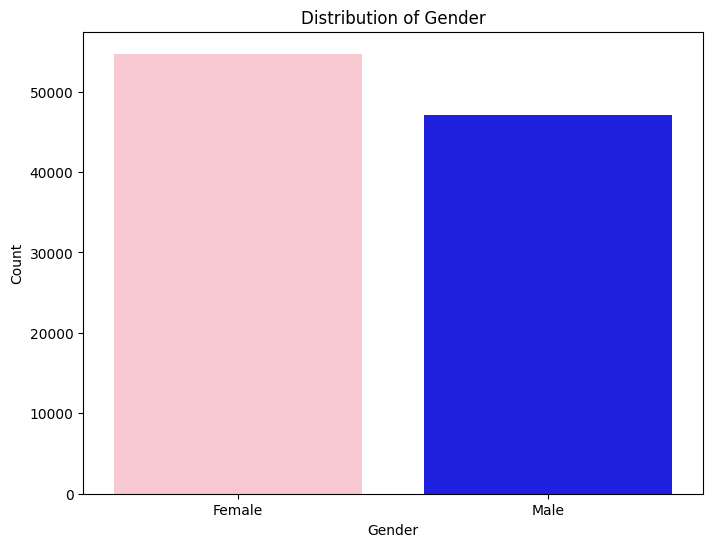

In [227]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'gender_Male' or 'gender_Female' is the column that exists after one-hot encoding.
# We will create a temporary column for display with original gender labels.
gender_display_col = None
if 'gender_Male' in df.columns:
    gender_display_col = 'gender_Male'
    # Map 1 to Male and 0 to Female (since gender_Female would be dropped)
    display_labels = {1: 'Male', 0: 'Female'}
elif 'gender_Female' in df.columns:
    gender_display_col = 'gender_Female'
    # Map 1 to Female and 0 to Male (since gender_Male would be dropped)
    display_labels = {1: 'Female', 0: 'Male'}

if gender_display_col:
    print(f"Distribution of original gender (derived from '{gender_display_col}' column):")
    # Convert boolean column to integer before mapping
    gender_for_plot = df[gender_display_col].astype(int).map(display_labels)
    display(gender_for_plot.value_counts())

    plt.figure(figsize=(8, 6))
    # Define a custom palette: pink for Female, blue for Male
    custom_gender_palette = {'Female': 'pink', 'Male': 'blue'}
    sns.countplot(x=gender_for_plot, hue=gender_for_plot, palette=custom_gender_palette, legend=False)
    plt.title('Distribution of Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.show()
else:
    print("Could not find a one-hot encoded 'gender' column (gender_Male or gender_Female).")

Now, let's look at the 'age' distribution.

Distribution of 'age' column:


,count
age,
5,161
15,691
25,1657
35,3775
45,9685
55,17256
65,22482
75,26066
85,17197


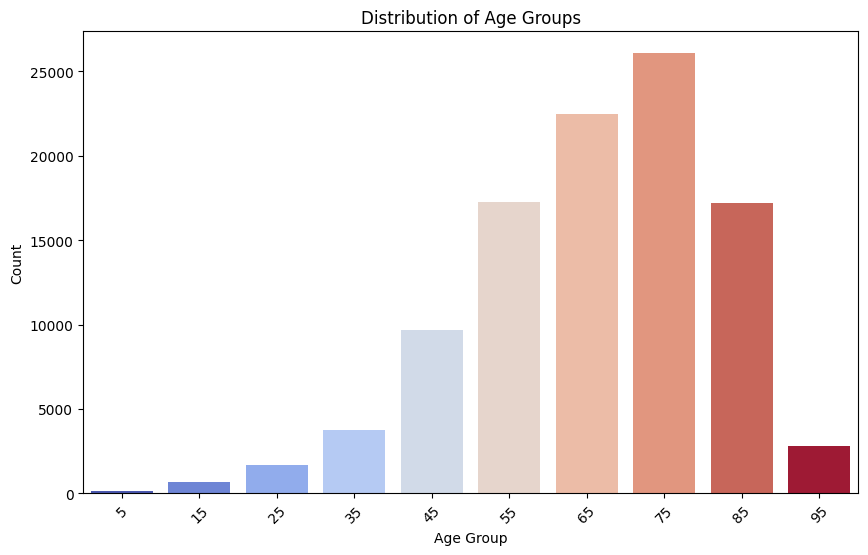

In [228]:
print("Distribution of 'age' column:")
display(df['age'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(x='age', data=df, hue='age', palette='coolwarm', order=sorted(df['age'].unique()), legend=False)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Correlation Heatmap for Numerical Columns

Let's visualize the correlation between the numerical features to identify any strong relationships.

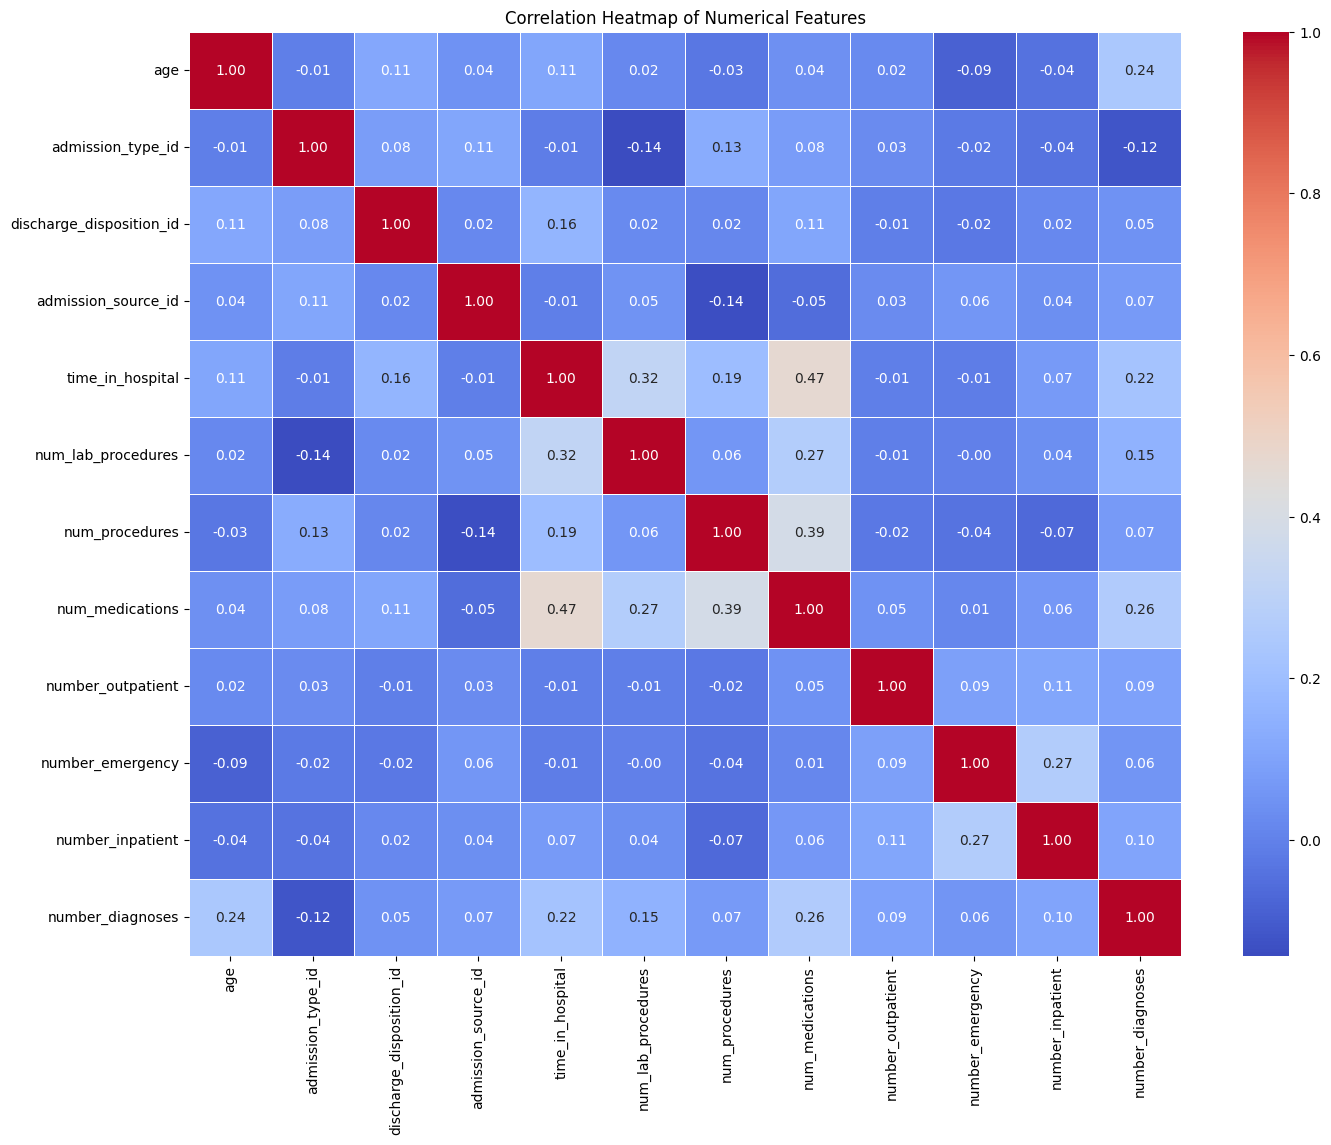

In [229]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Outlier Detection using IQR Method

Now, let's identify potential outliers in the numerical columns using the Interquartile Range (IQR) method. Outliers can significantly influence model training, so understanding their presence is crucial.

In [230]:
# Identify numerical columns for outlier detection
# Exclude 'encounter_id' and 'patient_nbr' as they are identifiers and not typically subject to outlier analysis
numerical_cols_for_outliers = [col for col in df.select_dtypes(include=np.number).columns if col not in ['encounter_id', 'patient_nbr']]

outlier_counts = {}

print("\nOutlier Detection using IQR Method:")
for column in numerical_cols_for_outliers:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_count = len(outliers)

    outlier_counts[column] = outlier_count

    if outlier_count > 0:
        print(f"  Column '{column}': {outlier_count} outliers detected.")
    else:
        print(f"  Column '{column}': No outliers detected.")

# Optionally, display a summary of columns with outliers
columns_with_outliers = {k: v for k, v in outlier_counts.items() if v > 0}
if columns_with_outliers:
    print("\nSummary of columns with detected outliers:")
    for col, count in columns_with_outliers.items():
        print(f"  - {col}: {count} outliers")
else:
    print("\nNo outliers detected in the numerical columns based on the IQR method.")


Outlier Detection using IQR Method:
  Column 'age': 852 outliers detected.
  Column 'admission_type_id': 341 outliers detected.
  Column 'discharge_disposition_id': 9817 outliers detected.
  Column 'admission_source_id': 6956 outliers detected.
  Column 'time_in_hospital': 2252 outliers detected.
  Column 'num_lab_procedures': 143 outliers detected.
  Column 'num_procedures': 4954 outliers detected.
  Column 'num_medications': 2557 outliers detected.
  Column 'number_outpatient': 16739 outliers detected.
  Column 'number_emergency': 11383 outliers detected.
  Column 'number_inpatient': 7049 outliers detected.
  Column 'number_diagnoses': 281 outliers detected.

Summary of columns with detected outliers:
  - age: 852 outliers
  - admission_type_id: 341 outliers
  - discharge_disposition_id: 9817 outliers
  - admission_source_id: 6956 outliers
  - time_in_hospital: 2252 outliers
  - num_lab_procedures: 143 outliers
  - num_procedures: 4954 outliers
  - num_medications: 2557 outliers
  -

### Visualizing Outliers with Boxplots

Let's visualize the distribution of our numerical features using boxplots to get a better sense of where outliers might exist. This complements the IQR-based outlier detection we performed earlier.

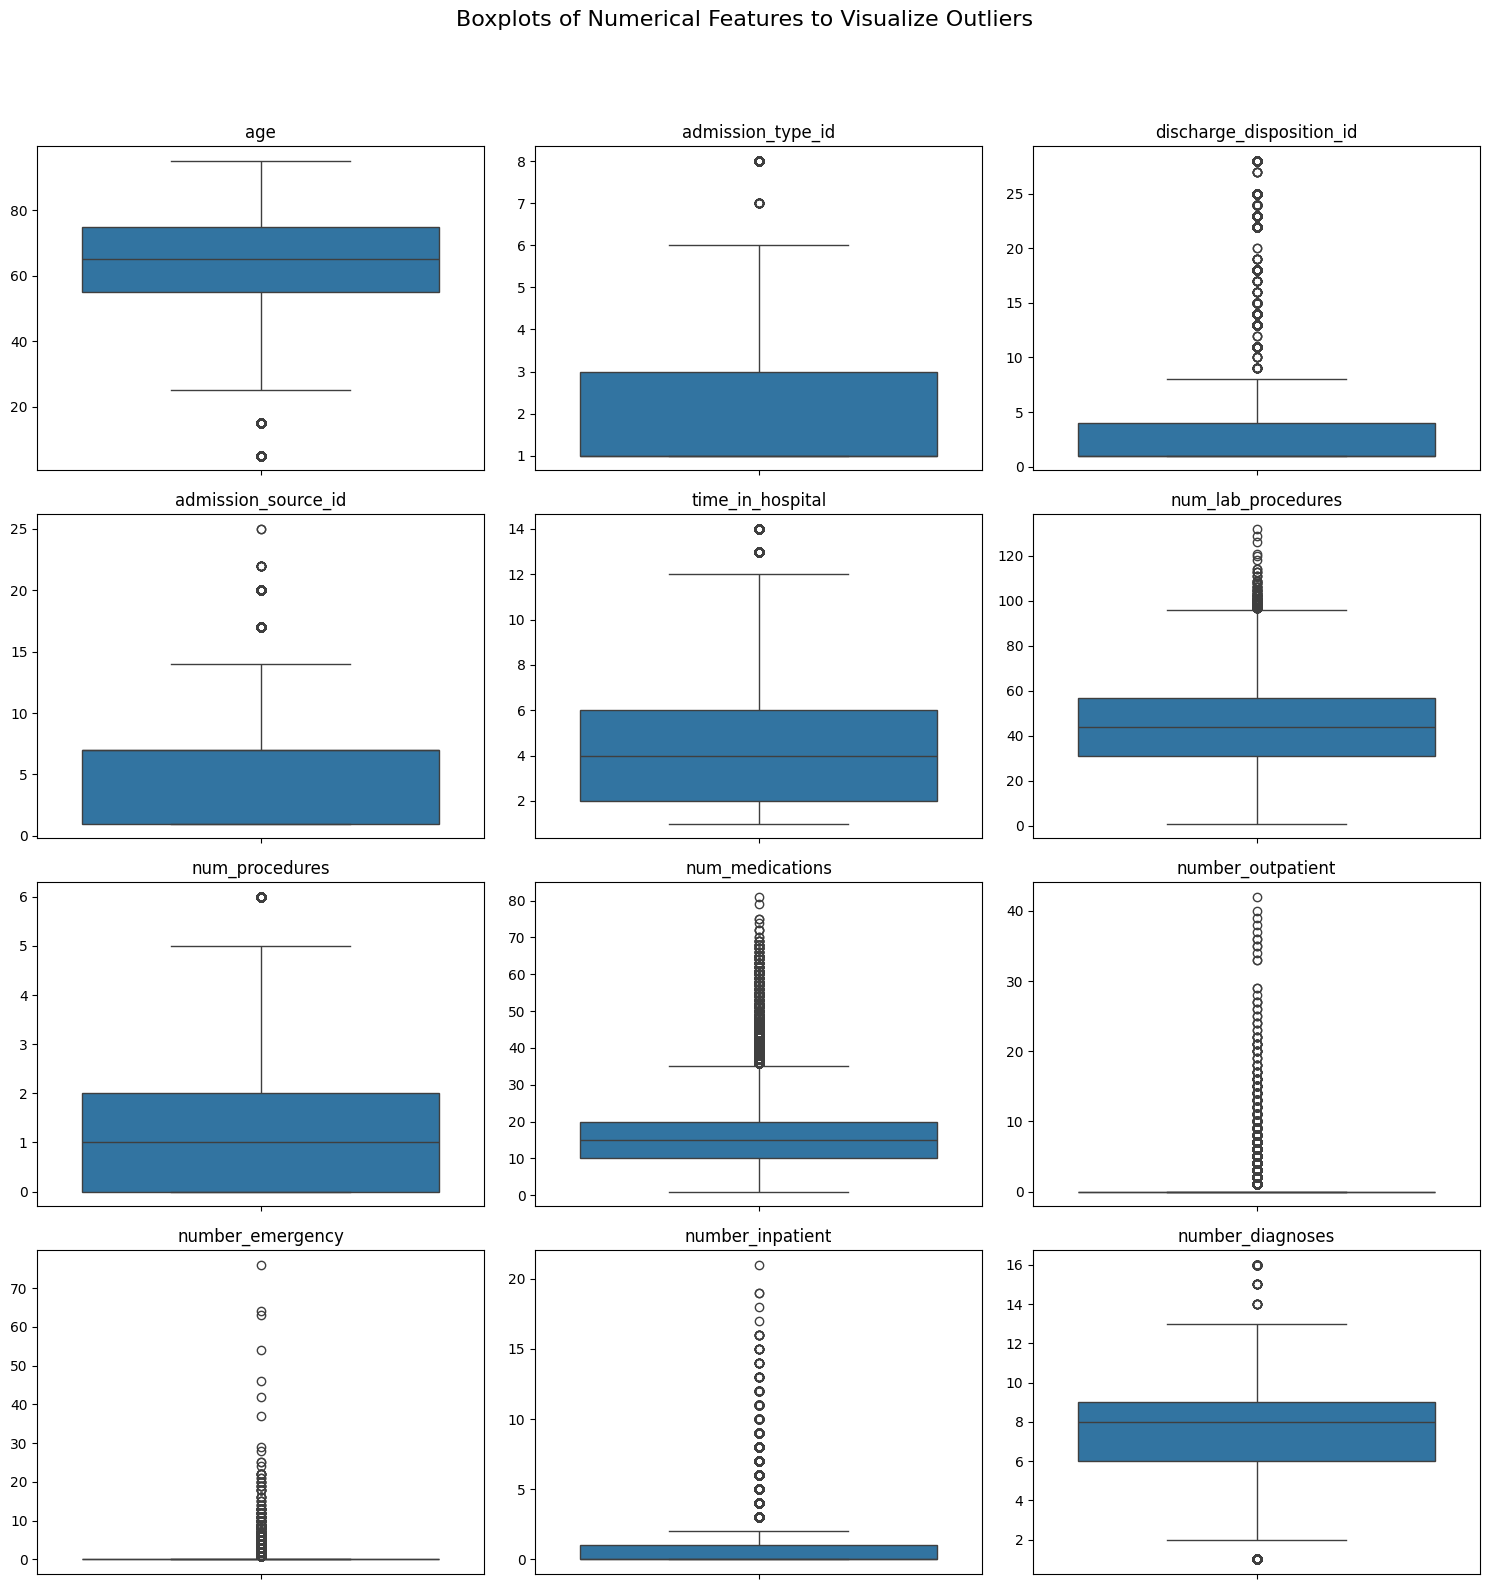

In [231]:
# Identify numerical columns for boxplot visualization
# Use the 'df' DataFrame at this stage, before feature engineering
numerical_cols_for_boxplot = df.select_dtypes(include=np.number).columns.tolist()

# Exclude identifier columns if they don't represent measurable quantities for outliers
id_cols = ['encounter_id', 'patient_nbr']
numerical_cols_for_boxplot = [col for col in numerical_cols_for_boxplot if col not in id_cols]

# Determine the number of rows and columns for subplots
num_plots = len(numerical_cols_for_boxplot)
num_cols = 3  # For example, 3 columns per row
num_rows = (num_plots + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Boxplots of Numerical Features to Visualize Outliers', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols_for_boxplot):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel('') # Remove y-label to avoid clutter

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent titles from overlapping
plt.show()

### Handling Outliers: Capping using IQR Method

Based on the outlier detection and visualization, we will now cap the outliers in the numerical columns using the IQR method. This involves setting any value below the lower bound to the lower bound, and any value above the upper bound to the upper bound. This helps to reduce the influence of extreme values without removing them entirely, which can be useful when these extreme values might contain valuable information or are part of the true data distribution.

In [232]:
# Apply outlier capping using the IQR method
# Identify numerical columns for outlier capping
# Exclude 'encounter_id' and 'patient_nbr' as they are identifiers
numerical_cols_for_capping = [col for col in df.select_dtypes(include=np.number).columns if col not in ['encounter_id', 'patient_nbr']]

print("Applying outlier capping for numerical columns...")
for column in numerical_cols_for_capping:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    print(f"  Column '{column}' capped. Values outside [{lower_bound:.2f}, {upper_bound:.2f}] have been adjusted.")

print("Outlier capping completed. Displaying descriptive statistics after capping:")
display(df[numerical_cols_for_capping].describe())

Applying outlier capping for numerical columns...
  Column 'age' capped. Values outside [25.00, 105.00] have been adjusted.
  Column 'admission_type_id' capped. Values outside [-2.00, 6.00] have been adjusted.
  Column 'discharge_disposition_id' capped. Values outside [-3.50, 8.50] have been adjusted.
  Column 'admission_source_id' capped. Values outside [-8.00, 16.00] have been adjusted.
  Column 'time_in_hospital' capped. Values outside [-4.00, 12.00] have been adjusted.
  Column 'num_lab_procedures' capped. Values outside [-8.00, 96.00] have been adjusted.
  Column 'num_procedures' capped. Values outside [-3.00, 5.00] have been adjusted.
  Column 'num_medications' capped. Values outside [-5.00, 35.00] have been adjusted.
  Column 'number_outpatient' capped. Values outside [0.00, 0.00] have been adjusted.
  Column 'number_emergency' capped. Values outside [0.00, 0.00] have been adjusted.
  Column 'number_inpatient' capped. Values outside [-1.50, 2.50] have been adjusted.
  Column 'nu

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.0,101763.0,101763.000000,101763.000000
mean,66.066399,2.017521,2.767327,5.680611,4.363649,43.087478,1.291010,15.808496,0.0,0.0,0.513698,7.422437
std,15.640915,1.422934,2.563722,3.860117,2.892162,19.648772,1.581863,7.396647,0.0,0.0,0.811342,1.925302
min,25.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.0,0.0,0.000000,1.500000
25%,55.000000,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.0,0.0,0.000000,6.000000
50%,65.000000,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.0,0.0,0.000000,8.000000
75%,75.000000,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.0,0.0,1.000000,9.000000
max,95.000000,6.000000,8.500000,16.000000,12.000000,96.000000,5.000000,35.000000,0.0,0.0,2.500000,13.500000


### Visualizing Outliers After Capping with Boxplots

Now, let's visualize the numerical features again using boxplots to confirm the effect of outlier capping. We should see that the extreme values (outliers) are now contained within the defined bounds.

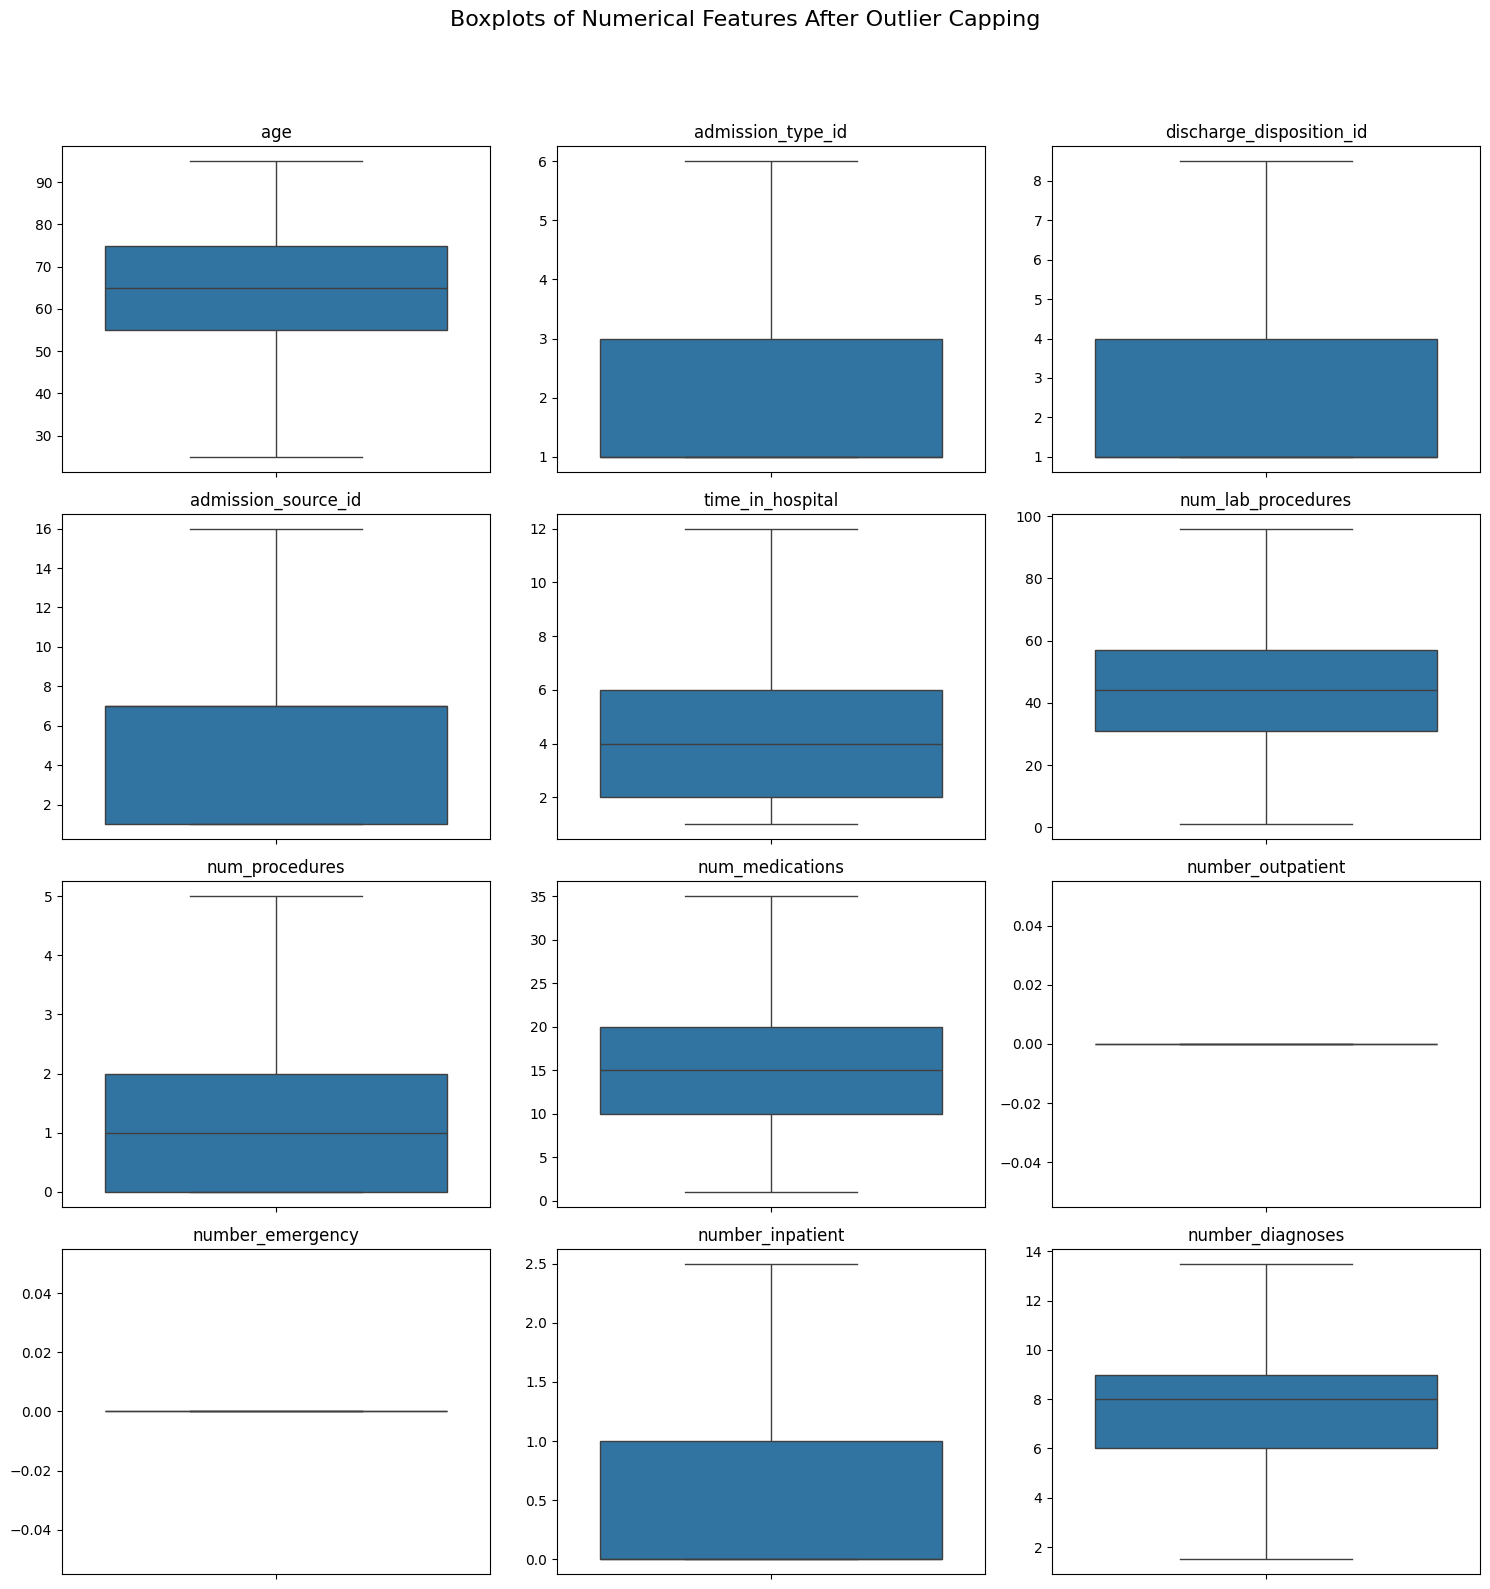

In [233]:
# Identify numerical columns for boxplot visualization
# Use the 'df' DataFrame that has undergone capping
numerical_cols_for_boxplot_after_capping = df.select_dtypes(include=np.number).columns.tolist()

# Exclude identifier columns if they don't represent measurable quantities for outliers
id_cols = ['encounter_id', 'patient_nbr']
numerical_cols_for_boxplot_after_capping = [col for col in numerical_cols_for_boxplot_after_capping if col not in id_cols]

# Determine the number of rows and columns for subplots
num_plots = len(numerical_cols_for_boxplot_after_capping)
num_cols = 3  # For example, 3 columns per row
num_rows = (num_plots + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Boxplots of Numerical Features After Outlier Capping', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols_for_boxplot_after_capping):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel('') # Remove y-label to avoid clutter

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent titles from overlapping
plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

Now that we have explored some categorical features, we will move to Problem 5: Engineering Features to prepare our data for modeling.

For Problem 5: Engineering Features, we will focus on transforming our raw data into a format suitable for machine learning models. This typically involves:

1.  **Encoding Categorical Variables:** Many features like 'race', 'gender', 'age', 'payer_code', and drug-related columns are categorical. We'll need to convert these into numerical representations using techniques like one-hot encoding or label encoding.
2.  **Handling Numerical Features:** While most numerical features appear clean, we might consider scaling them if necessary, especially for models sensitive to feature scales.
3.  **Target Variable Transformation:** The 'readmitted' column needs to be converted into a binary target (e.g., 0 for no readmission, 1 for readmission within 30 days).
4.  **Feature Selection/Creation:** Based on our EDA, we might identify features that are highly correlated with the target or create new features that could improve model performance.

The data preprocessing and feature engineering steps, including handling missing values, encoding categorical features, and transforming the target variable, have been executed in the earlier data cleaning and setup cells (notably cell `615a5860`).

Specifically:

*   **Missing values ('?'):** Columns like `race`, `diag_1`, `diag_2`, `diag_3`, `payer_code` had '?' values replaced with their mode.
*   **NaN values:** `max_glu_serum` and `A1Cresult` NaNs were filled with 'None'.
*   **Dropping columns:** `weight`, `medical_specialty`, `encounter_id`, and `patient_nbr` were dropped.
*   **Gender encoding:** 'gender's 'Unknown/Invalid' entries were removed, and the column was one-hot encoded.
*   **Age encoding:** The 'age' ranges were ordinally encoded to their midpoint values.
*   **Outlier capping:** Numerical outliers were capped using the IQR method.
*   **Target variable:** The `readmitted` column was transformed into a binary `readmitted_binary` (1 for `<30`, 0 otherwise).
*   **One-Hot Encoding and Scaling:** The `preprocessor` (defined in cell `615a5860`) handles one-hot encoding for the remaining categorical features and standard scaling for numerical features.

Below, we display the first few rows of the processed DataFrame (`df_processed`) and the shapes of the feature matrix (`X`) and target vector (`y`) after these transformations.

### Encoding Categorical Features: 'gender' and 'age'

Reasoning: The next step in exploratory data analysis is to generate descriptive statistics for numerical columns to understand their distribution and central tendencies. The df.describe() method is perfect for this.


In [234]:
print("Descriptive Statistics for Numerical Columns:")
print(df.describe())

Descriptive Statistics for Numerical Columns:
                 age  admission_type_id  discharge_disposition_id  \
count  101763.000000      101763.000000             101763.000000   
mean       66.066399           2.017521                  2.767327   
std        15.640915           1.422934                  2.563722   
min        25.000000           1.000000                  1.000000   
25%        55.000000           1.000000                  1.000000   
50%        65.000000           1.000000                  1.000000   
75%        75.000000           3.000000                  4.000000   
max        95.000000           6.000000                  8.500000   

       admission_source_id  time_in_hospital  num_lab_procedures  \
count        101763.000000     101763.000000       101763.000000   
mean              5.680611          4.363649           43.087478   
std               3.860117          2.892162           19.648772   
min               1.000000          1.000000            1.00

Reasoning: To analyze the distribution of categorical features, I need to identify them first and then print their value counts to see the unique categories and their frequencies.


In [235]:
print("Distribution of Categorical Features:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Distribution of Categorical Features:

Column: race
race
Caucasian          78370
AfricanAmerican    19210
Hispanic            2037
Other               1505
Asian                641
Name: count, dtype: int64

Column: payer_code
payer_code
MC    72694
HM     6274
SP     5007
BC     4655
MD     3532
CP     2531
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

Column: diag_1
diag_1
428    6883
414    6580
786    4016
410    3614
486    3508
       ... 
833       1
391       1
690       1
10        1
V51       1
Name: count, Length: 716, dtype: int64

Column: diag_2
diag_2
276    7110
428    6662
250    6071
427    5036
401    3736
       ... 
123       1
884       1
V60       1
843       1
927       1
Name: count, Length: 748, dtype: int64

Column: diag_3
diag_3
250    12978
401     8288
276     5175
428     4577
427     3955
       ...  
14         1
750        1
370        1
671

Reasoning: To visualize numerical distributions, I need to plot histograms for each numerical column. I will use matplotlib.pyplot and seaborn for this, ensuring proper titles and layouts.


In [236]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# import various functions from statsmodels
import statsmodels
import statsmodels.api as sm

# import StandardScaler to perform scaling
from sklearn.preprocessing import StandardScaler

# import various functions from sklearn
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score

# Create a copy of the DataFrame to work with for processing
df_processed = df.copy()

# Convert the 'readmitted' column into a binary target variable
# 1 if readmitted within 30 days ('<30'), 0 otherwise ('NO', '>30')
df_processed['readmitted_binary'] = df_processed['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Drop the original 'readmitted' column as we now have 'readmitted_binary'
df_processed = df_processed.drop('readmitted', axis=1)

# Separate features (X) and target (y)
X = df_processed.drop('readmitted_binary', axis=1)
y = df_processed['readmitted_binary']

# Identify categorical and numerical columns for transformation based on X
categorical_features = X.select_dtypes(include='object').columns.tolist()
# The following line was trying to remove 'readmitted' and 'readmitted_binary' from X, which are no longer present.
# categorical_features = [col for col in categorical_features if col not in ['readmitted', 'readmitted_binary']]

# Limit to the top 10 categorical features as requested in earlier instructions or use the explicit list
# Based on previous context, these features were identified as relevant and limited:
# categorical_features = categorical_features[:20]
categorical_features = ['race', 'payer_code', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin']
# The OneHotEncoder in the ColumnTransformer below converts these categorical features to numeric.
print(f"Categorical features identified for preprocessing: {categorical_features}")

# The actual encoding of these features will be handled by the OneHotEncoder within the ColumnTransformer defined below.
# The previous `label_encoders` loop has been removed as it was attempting to perform a different type of encoding
# on an undefined DataFrame, and it would conflict with the ColumnTransformer's OneHotEncoder.

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove identifier columns from numerical features if they are not meant for scaling/modeling
id_cols = ['encounter_id', 'patient_nbr']
numerical_features = [col for col in numerical_features if col not in id_cols]

print("Features (X) and Target (y) prepared for transformation.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Create a column transformer for preprocessing (but don't fit_transform yet)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop' # Change 'passthrough' to 'drop' to avoid non-numeric columns in sparse output
)

Categorical features identified for preprocessing: ['race', 'payer_code', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin']
Features (X) and Target (y) prepared for transformation.
Shape of X: (101763, 45)
Shape of y: (101763,)


We scale the variables to get all the variables in the same range. With this, we can avoid a problem in which some features come to dominate solely because they tend to have larger values than others.

We scale the variables to get all the variables in the same range. With this, we can avoid a problem in which some features come to dominate solely because they tend to have larger values than others.

### Clarification on Feature Selection

The `ColumnTransformer` defined in the previous cell (`DeBqc_8Gq7DO`) already performs the desired feature limiting. Specifically:

*   **`numerical_features`**: These are identified and processed using `StandardScaler`.
*   **`categorical_features`**: This list is explicitly defined to include only `['race', 'payer_code', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin']`, which are then one-hot encoded.
*   **`remainder='drop'`**: Any columns in the original `X` that are *not* explicitly mentioned in either `numerical_features` or `categorical_features` are dropped from the transformed output.

Therefore, the `X_transformed` (generated in cell `59b8ac53`) already contains only the numerical features and the selected categorical features in their processed form, fulfilling the requirement to limit the columns.

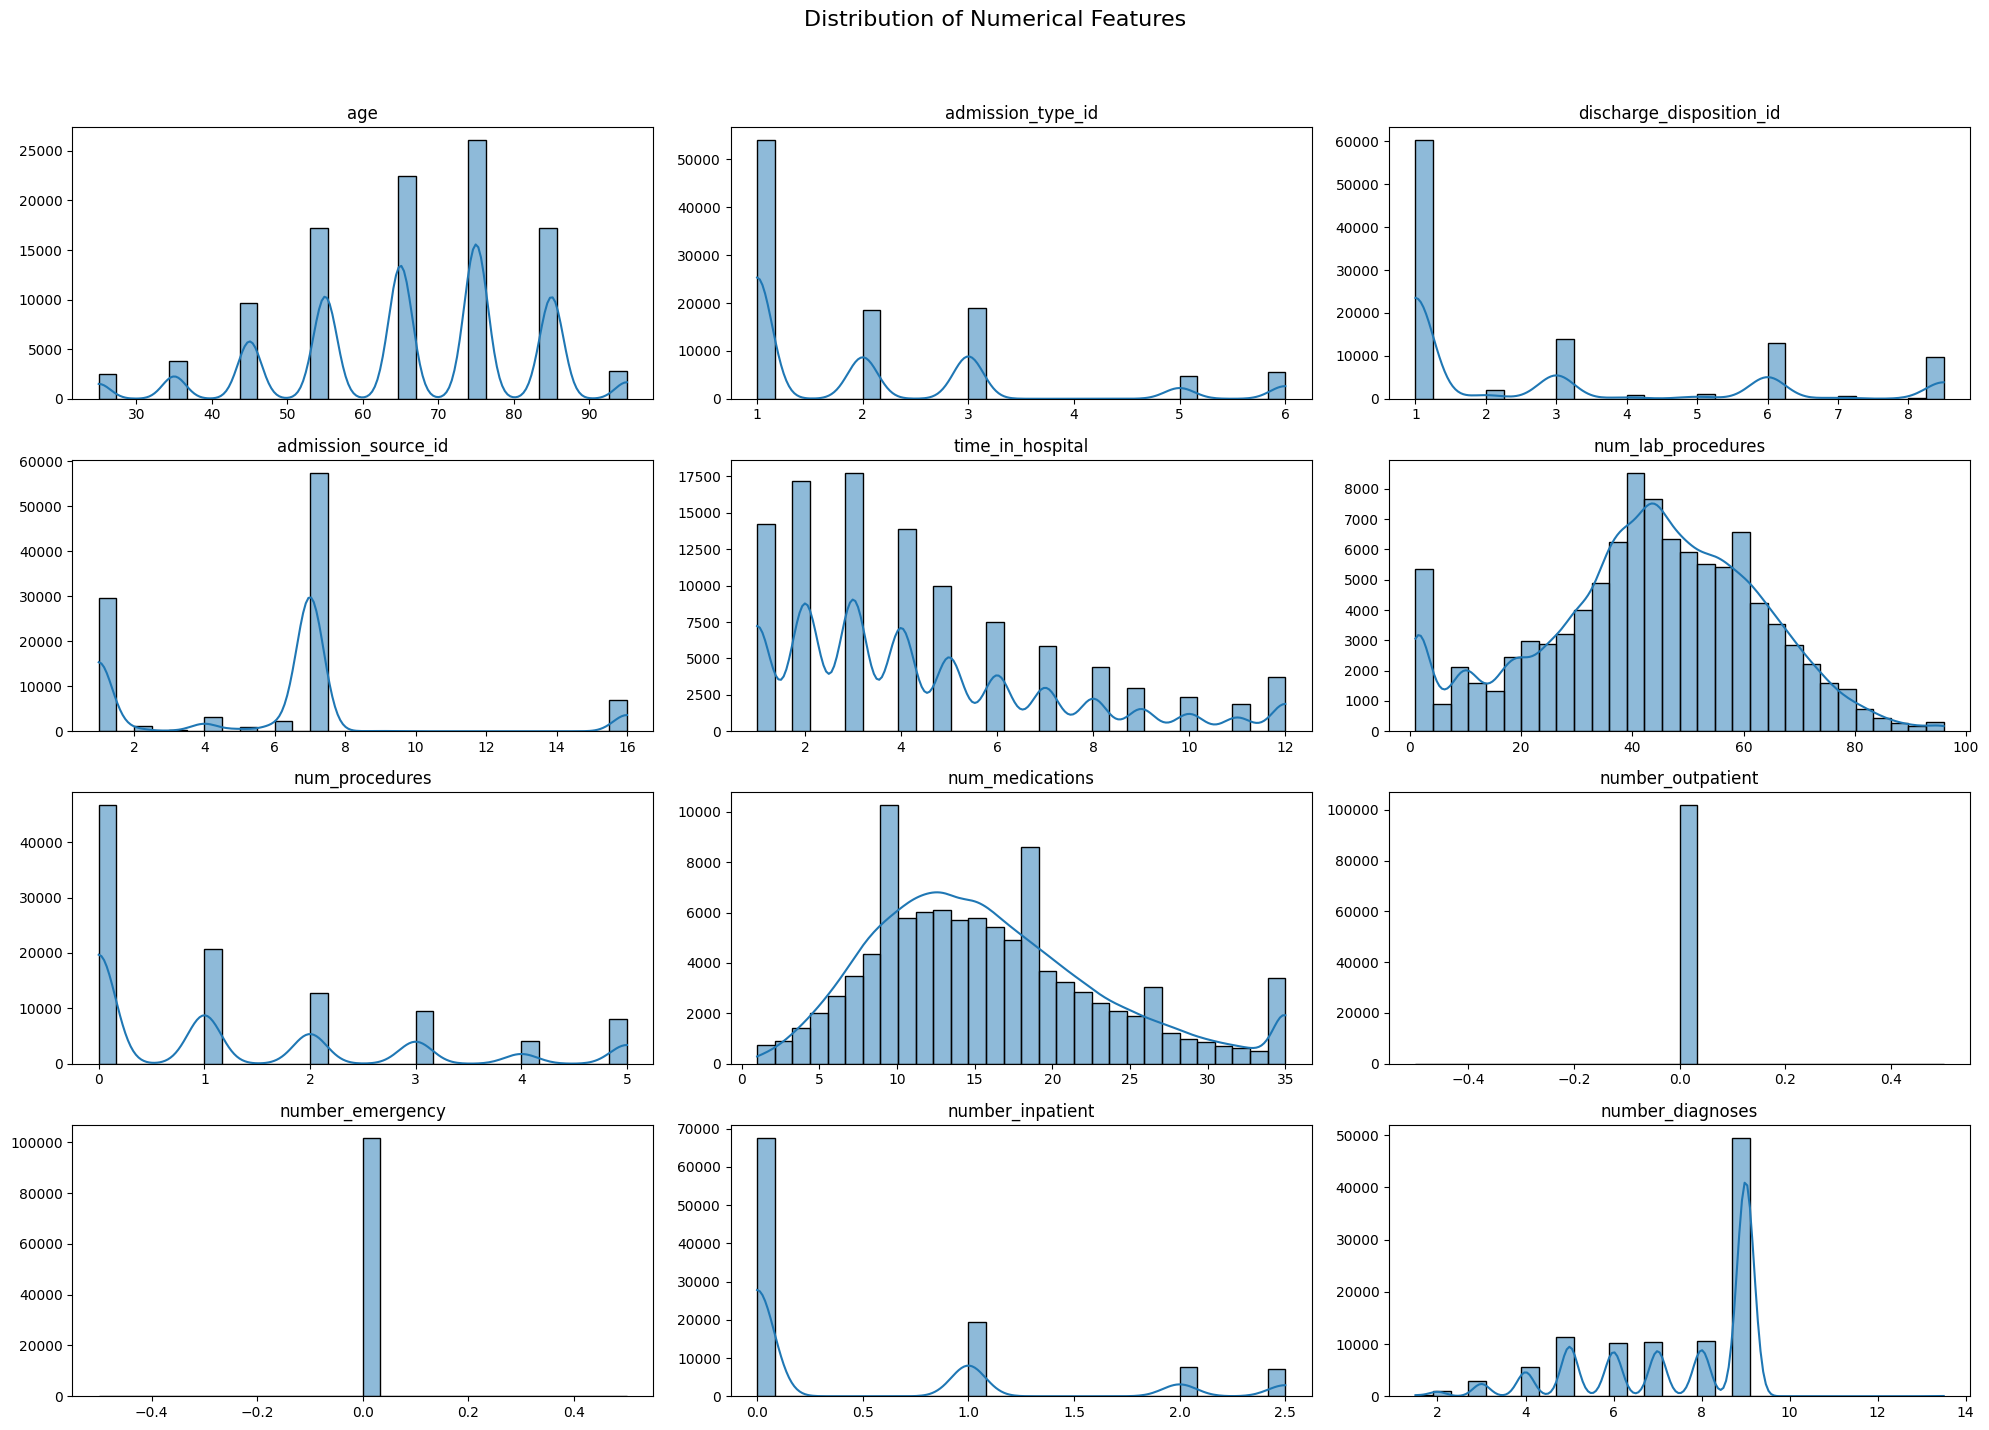

In [237]:
# Plot histograms for numerical features

# Identify numerical columns from X (excluding identifier columns)
numerical_cols_for_hist = [col for col in X.select_dtypes(include=np.number).columns if col not in ['encounter_id', 'patient_nbr']]

# Set up the matplotlib figure and axes
fig = plt.figure(figsize=(20, 15))
fig.suptitle('Distribution of Numerical Features', fontsize=16)

for i, col in enumerate(numerical_cols_for_hist):
    ax = fig.add_subplot(4, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df_processed[col], kde=True, ax=ax, bins=30) # Using df_processed as it has age encoded
    ax.set_title(col)
    ax.set_xlabel('') # Remove x-label to avoid clutter
    ax.set_ylabel('') # Remove y-label to avoid clutter

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent titles from overlapping
plt.show()

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [238]:
from sklearn.model_selection import train_test_split

# Transform the features using the preprocessor
X_transformed = preprocessor.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (81410, 2297)
Shape of X_test: (20353, 2297)
Shape of y_train: (81410,)
Shape of y_test: (20353,)


### Addressing Class Imbalance with SMOTE

Given the significant class imbalance observed in the `readmitted_binary` target variable, we will use **SMOTE (Synthetic Minority Over-sampling Technique)** to oversample the minority class (`readmitted = 1`) in the training data. This helps prevent models from being biased towards the majority class and improves their ability to correctly identify readmitted patients.

In [239]:
# Install imbalanced-learn if not already installed
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    %pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

print("Applying SMOTE to the training data...")

smt = SMOTE(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("SMOTE sampling complete.")
print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_train_res.shape}, {y_train_res.shape}")

print("\nClass distribution after SMOTE:")
print(y_train_res.value_counts())

Applying SMOTE to the training data...
SMOTE sampling complete.
Original training set shape: (81410, 2297), (81410,)
Resampled training set shape: (144648, 2297), (144648,)

Class distribution after SMOTE:
readmitted_binary
0    72324
1    72324
Name: count, dtype: int64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

Majority class in training set: 0
Baseline Accuracy (predicting majority class 0): 0.8884

Baseline Confusion Matrix:
[[18082     0]
 [ 2271     0]]


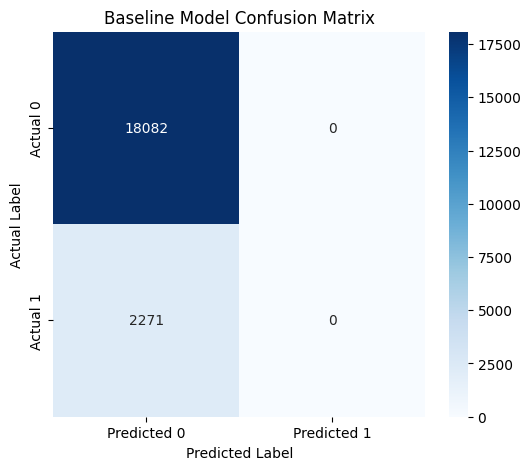


Classification Report for Baseline Model:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20353
   macro avg       0.44      0.50      0.47     20353
weighted avg       0.79      0.89      0.84     20353



In [240]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Determine the majority class in the training set
majority_class = y_train.mode()[0]
print(f"Majority class in training set: {majority_class}")

# Create baseline predictions (always predict the majority class)
baseline_predictions = [majority_class] * len(y_test)

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
print(f"Baseline Accuracy (predicting majority class {majority_class}): {baseline_accuracy:.4f}")

# Generate confusion matrix for the baseline model
baseline_cm = confusion_matrix(y_test, baseline_predictions)
print("\nBaseline Confusion Matrix:")
print(baseline_cm)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(baseline_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Baseline Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate the classification report for the baseline model
baseline_report = classification_report(y_test, baseline_predictions, zero_division=0)
print("\nClassification Report for Baseline Model:")
print(baseline_report)

### Interpreting the Baseline Confusion Matrix

*   **True Negatives (TN):** Top-left value. These are cases where the model correctly predicted 0 (no readmission).
*   **False Positives (FP):** Top-right value. These are cases where the model incorrectly predicted 1 (readmission) when the actual value was 0.
*   **False Negatives (FN):** Bottom-left value. These are cases where the model incorrectly predicted 0 (no readmission) when the actual value was 1.
*   **True Positives (TP):** Bottom-right value. These are cases where the model correctly predicted 1 (readmission).

For a baseline model that always predicts the majority class (which is `0` in our case, meaning no readmission), the confusion matrix will show:

*   A large number in the **True Negatives** (TN) cell, corresponding to all the actual 0s that were correctly predicted as 0.
*   A large number in the **False Negatives** (FN) cell, corresponding to all the actual 1s that were incorrectly predicted as 0.
*   **Zero** in the **False Positives** (FP) cell, because the model never predicts 1.
*   **Zero** in the **True Positives** (TP) cell, because the model never predicts 1.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [241]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(solver='liblinear', random_state=42)

# Train the model on the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Problem 9: Score the Model

What is the accuracy of your model?

Model Accuracy: 0.8887

Model Confusion Matrix:
[[18074     8]
 [ 2258    13]]


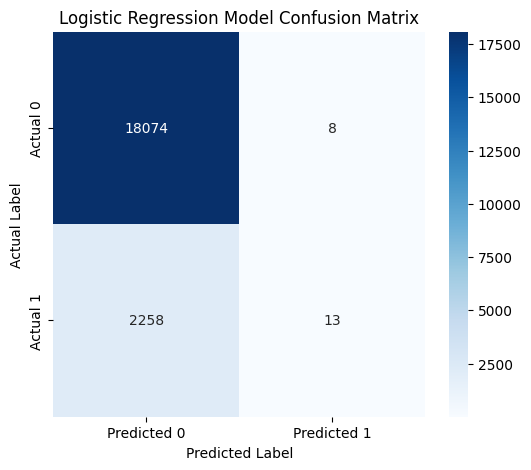


Classification Report for Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.62      0.01      0.01      2271

    accuracy                           0.89     20353
   macro avg       0.75      0.50      0.48     20353
weighted avg       0.86      0.89      0.84     20353



In [242]:
# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Generate and display the confusion matrix
model_cm = confusion_matrix(y_test, y_pred)
print("\nModel Confusion Matrix:")
print(model_cm)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report = classification_report(y_test, y_pred, zero_division=0)
print("\nClassification Report for Logistic Regression Model:")
print(model_report)

### Improving the Model: Addressing Class Imbalance with Class Weights

As observed, the initial Logistic Regression model performed no better than the baseline in predicting readmissions (the minority class). This is a common issue with imbalanced datasets. One way to mitigate this is by using `class_weight='balanced'` in the Logistic Regression model. This parameter automatically adjusts weights inversely proportional to class frequencies in the input data, effectively telling the model to pay more attention to the minority class.

Logistic Regression model trained with balanced class weights successfully.

Model Accuracy (with balanced class weights): 0.6387

Model Confusion Matrix (with balanced class weights):
[[11746  6336]
 [ 1018  1253]]


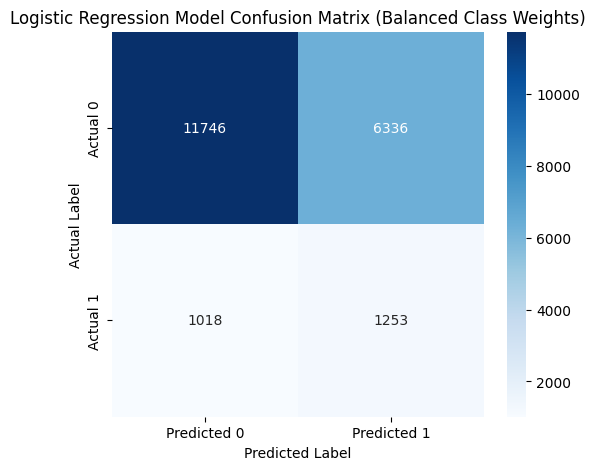


Classification Report for Logistic Regression Model (Balanced Class Weights):
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     18082
           1       0.17      0.55      0.25      2271

    accuracy                           0.64     20353
   macro avg       0.54      0.60      0.51     20353
weighted avg       0.84      0.64      0.70     20353



In [243]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Re-initialize the Logistic Regression model with class_weight='balanced'
# This will automatically adjust weights inversely proportional to class frequencies
logistic_model_balanced = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)

# Train the model on the training data
logistic_model_balanced.fit(X_train, y_train)

print("Logistic Regression model trained with balanced class weights successfully.")

# Make predictions on the test set
y_pred_balanced = logistic_model_balanced.predict(X_test)

# Calculate accuracy
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
print(f"\nModel Accuracy (with balanced class weights): {accuracy_balanced:.4f}")

# Generate and display the confusion matrix
model_cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print("\nModel Confusion Matrix (with balanced class weights):")
print(model_cm_balanced)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_balanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Model Confusion Matrix (Balanced Class Weights)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_balanced = classification_report(y_test, y_pred_balanced, zero_division=0)
print("\nClassification Report for Logistic Regression Model (Balanced Class Weights):")
print(model_report_balanced)

AUC-ROC Score for Logistic Regression Model (Balanced Class Weights): 0.6364


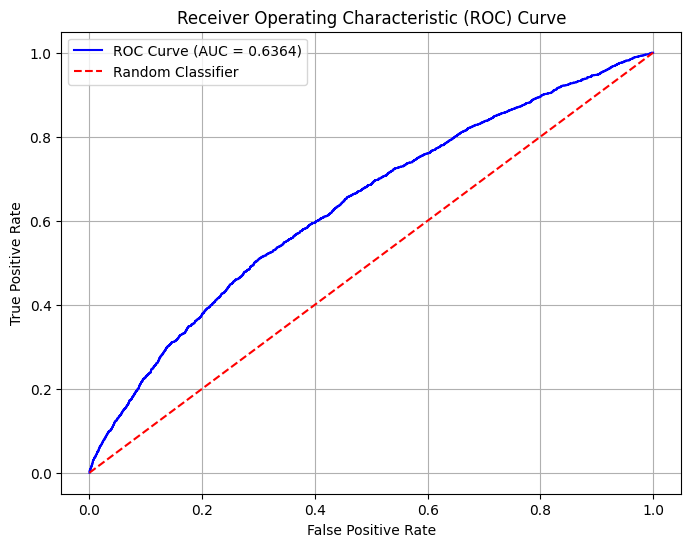

In [244]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities for the positive class (class 1)
y_pred_proba = logistic_model_balanced.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score for Logistic Regression Model (Balanced Class Weights): {auc_roc:.4f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [245]:
print("Checking for NaN columns in df_processed:")
# Get columns with any NaN values
nan_columns = df_processed.columns[df_processed.isnull().any()].tolist()

if nan_columns:
    print(f"Found NaN columns: {nan_columns}")
    # Drop columns with NaN values
    df_processed = df_processed.drop(columns=nan_columns)
    print(f"Dropped columns: {nan_columns}")
    print(f"New DataFrame shape: {df_processed.shape}")
else:
    print("No NaN columns found in df_processed. All missing values were handled in previous steps.")

display(df_processed.head())

Checking for NaN columns in df_processed:
No NaN columns found in df_processed. All missing values were handled in previous steps.


,race,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,gender_Male,readmitted_binary
0,Caucasian,25.0,6.0,8.5,1.0,1.0,MC,41.0,0.0,1.0,...,No,No,No,No,No,No,No,No,False,0
1,Caucasian,25.0,1.0,1.0,7.0,3.0,MC,59.0,0.0,18.0,...,Up,No,No,No,No,No,Ch,Yes,False,0
2,AfricanAmerican,25.0,1.0,1.0,7.0,2.0,MC,11.0,5.0,13.0,...,No,No,No,No,No,No,No,Yes,False,0
3,Caucasian,35.0,1.0,1.0,7.0,2.0,MC,44.0,1.0,16.0,...,Up,No,No,No,No,No,Ch,Yes,True,0
4,Caucasian,45.0,1.0,1.0,7.0,1.0,MC,51.0,0.0,8.0,...,Steady,No,No,No,No,No,Ch,Yes,True,0


In [246]:
# Select numerical columns from df_processed, including the target variable
# removed NAN columns 'number_outpatient','number_emergency'
numerical_cols_with_target = [col for col in df_processed.select_dtypes(include=np.number).columns
                              if col not in ['encounter_id', 'patient_nbr', 'number_outpatient','number_emergency']]




# Calculate the correlation matrix including the target
correlation_matrix_with_target = df_processed[numerical_cols_with_target].corr()

# Display correlations with the 'readmitted_binary' target variable
print("Correlation of features with 'readmitted_binary':")
display(correlation_matrix_with_target['readmitted_binary'].sort_values(ascending=False))

Correlation of features with 'readmitted_binary':


,readmitted_binary
readmitted_binary,1.000000
number_inpatient,0.148069
number_diagnoses,0.049656
discharge_disposition_id,0.049240
time_in_hospital,0.045062
num_medications,0.041585
num_lab_procedures,0.020347
age,0.016639
admission_source_id,0.006389
admission_type_id,-0.011405


A quick visual inspection of the heatmap might also be useful for broader relationships among numerical features and the target.

## Modeling

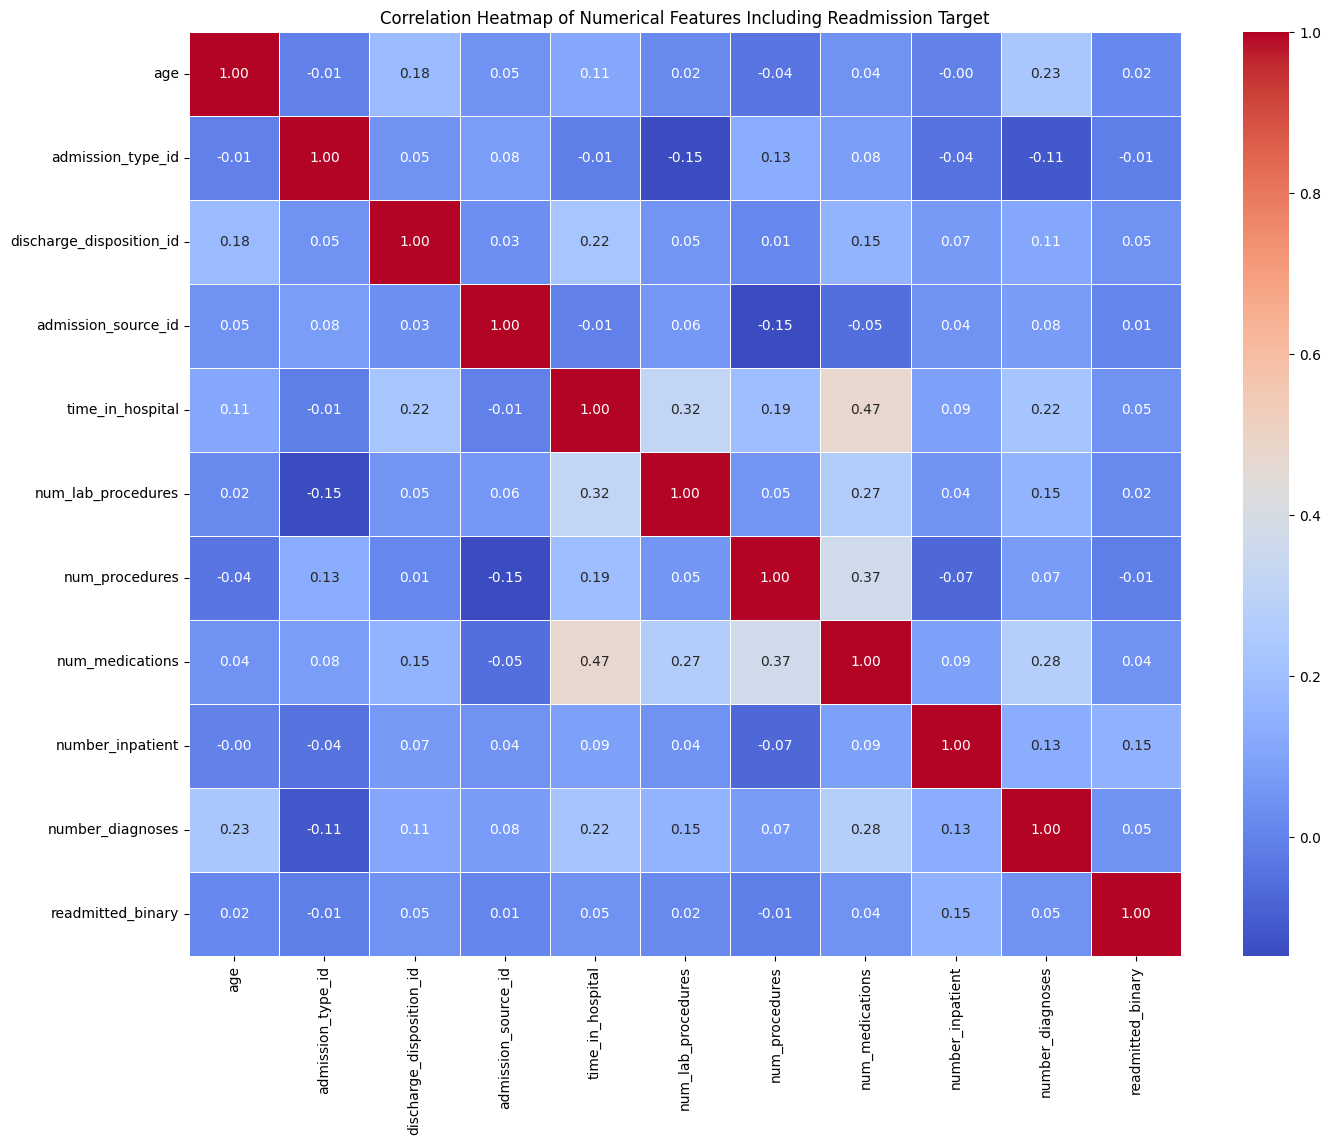

In [247]:
# Plot the full correlation heatmap, including the target
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix_with_target, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features Including Readmission Target')
plt.show()

### Tuning the Decision Threshold for Imbalanced Classes

For imbalanced datasets, the default classification threshold of 0.5 (where probabilities >= 0.5 are classified as the positive class) may not be optimal. By adjusting this threshold, we can often improve the model's ability to correctly identify the minority class (patients readmitted within 30 days) by trading off precision for recall, or vice-versa, depending on the business objective. In a healthcare setting like this, correctly identifying at-risk patients (maximizing recall for the positive class) is often prioritized over having very high precision (minimizing false alarms), as the cost of a false negative (missed readmission) can be much higher than a false positive.

We will explore different thresholds and evaluate their impact on precision, recall, and F1-score to find a more suitable operating point for our model.

Optimal Threshold based on F1-score: 0.5271


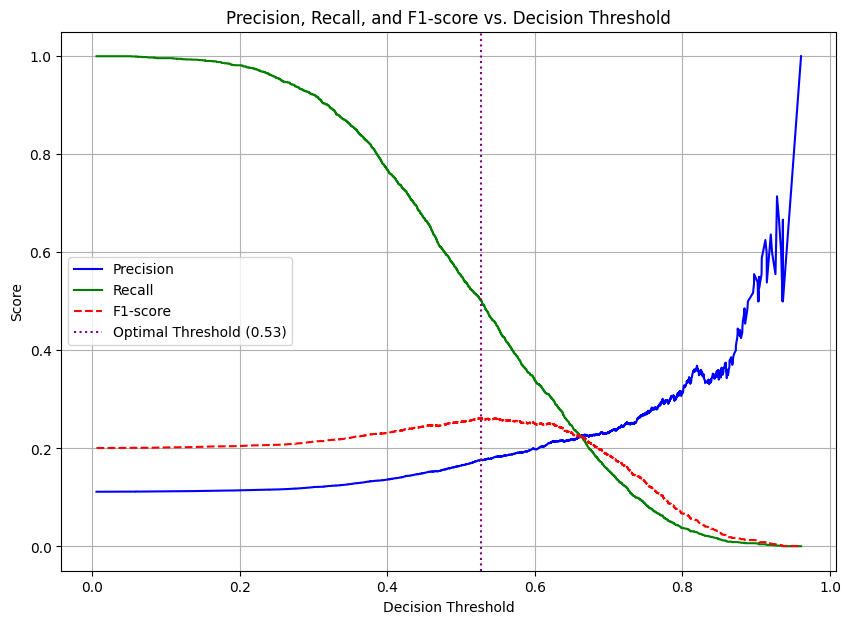


--- Model Evaluation with Tuned Threshold (0.5271) ---
Model Accuracy (with tuned threshold): 0.6831

Model Confusion Matrix (with tuned threshold):
[[12763  5319]
 [ 1130  1141]]


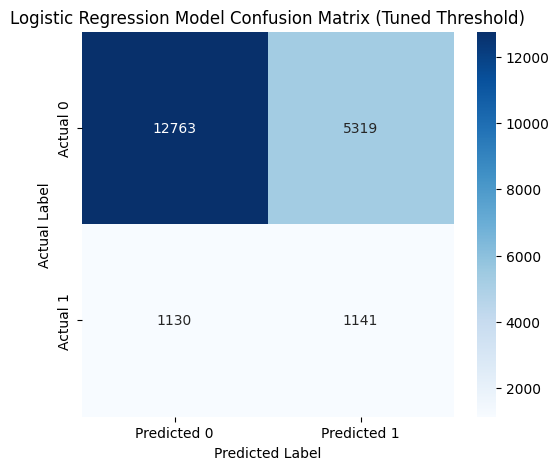


Classification Report for Logistic Regression Model (Tuned Threshold):
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18082
           1       0.18      0.50      0.26      2271

    accuracy                           0.68     20353
   macro avg       0.55      0.60      0.53     20353
weighted avg       0.84      0.68      0.74     20353


AUC-ROC Score (with tuned threshold): 0.6364


In [248]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get prediction probabilities for the positive class (class 1)
y_pred_proba = logistic_model_balanced.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds for various decision boundaries
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1-scores for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# Find the threshold that maximizes the F1-score (or another desired metric)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold based on F1-score: {optimal_threshold:.4f}")

# Plot Precision, Recall, and F1-score vs. Threshold
plt.figure(figsize=(10, 7))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores[:-1], label='F1-score', color='red', linestyle='--')
plt.axvline(x=optimal_threshold, color='purple', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score vs. Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Re-evaluate the model with the new optimal threshold
y_pred_tuned = (y_pred_proba >= optimal_threshold).astype(int)

print(f"\n--- Model Evaluation with Tuned Threshold ({optimal_threshold:.4f}) ---")

# Calculate accuracy
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Model Accuracy (with tuned threshold): {accuracy_tuned:.4f}")

# Generate and display the confusion matrix
model_cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("\nModel Confusion Matrix (with tuned threshold):")
print(model_cm_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Model Confusion Matrix (Tuned Threshold)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_tuned = classification_report(y_test, y_pred_tuned, zero_division=0)
print("\nClassification Report for Logistic Regression Model (Tuned Threshold):")
print(model_report_tuned)

# Calculate AUC-ROC score (remains the same as it's threshold-independent)
auc_roc_tuned = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC Score (with tuned threshold): {auc_roc_tuned:.4f}")

### Interpreting and Justifying Evaluation Metrics in an Imbalanced Healthcare Setting

In the context of predicting hospital readmissions, where the positive class (readmitted within 30 days) is significantly smaller than the negative class (not readmitted), it is crucial to move beyond simple accuracy as the primary evaluation metric. Here's why recall and AUC-ROC are more relevant and how they should be interpreted:

*   **Accuracy:** While seemingly intuitive, accuracy can be misleading in imbalanced datasets. A model that simply predicts 'no readmission' for every patient would achieve very high accuracy because the majority of patients are indeed not readmitted. However, such a model would be useless for identifying the high-risk individuals we are trying to target for intervention. For instance, if 90% of patients are not readmitted, a model predicting 'no readmission' for everyone would have 90% accuracy but miss all actual readmissions.

*   **Recall (Sensitivity or True Positive Rate):** Recall measures the proportion of actual positive cases (patients who *were* readmitted) that were correctly identified by the model. In this healthcare context, maximizing recall for the 'readmitted' class is often paramount. A high recall means that we are successfully catching most of the patients who are truly at risk of readmission. This is vital for implementing early interventions, patient education, and follow-up care to prevent adverse outcomes. A low recall would mean many high-risk patients are missed, leading to preventable readmissions.

*   **Precision (Positive Predictive Value):** Precision measures the proportion of positive predictions (patients the model predicted would be readmitted) that were actually correct. While important, especially to avoid unnecessarily burdening patients and healthcare resources with false alarms, a slight trade-off in precision might be acceptable if it significantly boosts recall. The cost of a false positive (identifying a patient as high-risk when they are not) might involve additional monitoring or follow-up, which is generally less severe than the cost of a false negative (missing a truly high-risk patient).

*   **F1-Score:** The F1-score is the harmonic mean of precision and recall. It provides a single metric that balances both concerns. It's particularly useful when you need to strike a balance between recall and precision, especially when the class distribution is uneven. A higher F1-score indicates a better balance between correctly identifying positive cases and minimizing false positive predictions.

*   **AUC-ROC (Area Under the Receiver Operating Characteristic Curve):** The AUC-ROC score measures the model's ability to distinguish between positive and negative classes across all possible classification thresholds. A key advantage of AUC-ROC is that it is **threshold-independent**, meaning it doesn't rely on a single decision threshold. This makes it a robust metric for evaluating overall model performance, especially in situations where the cost of false positives and false negatives might vary or need to be balanced. An AUC of 0.5 suggests the model performs no better than random guessing, while an AUC of 1.0 represents a perfect classifier. In healthcare, a higher AUC-ROC indicates that the model is generally better at ranking patients by their readmission risk, regardless of where the specific intervention threshold is set.

## Problem 10: Advanced Machine Learning Techniques for Readmission Prediction

Given the complexity of predicting hospital readmissions, several advanced machine learning techniques can be applied. Here are three methods, along with their benefits and how they would be used in this project:

### 1. Gradient Boosting Machines (e.g., XGBoost, LightGBM)

*   **Benefits:** Gradient Boosting Machines (GBMs) are powerful ensemble learning methods that build models sequentially, with each new model correcting errors made by previous ones. They are known for their high accuracy, robustness to outliers (especially with tree-based learners), and ability to handle various data types. They can also capture complex non-linear relationships and interactions between features.

*   **How it would be used:**
    1.  **Feature Importance:** GBMs can provide insights into feature importance, helping to identify which factors (e.g., number of medications, age, previous emergency visits) are most predictive of readmission.
    2.  **Prediction:** The trained GBM model would predict the probability of readmission for each patient. These probabilities can then be used to rank patients by risk, allowing healthcare providers to focus interventions on the highest-risk individuals.
    3.  **Handling Imbalance:** While not inherently handling imbalance as well as `class_weight='balanced'` in Logistic Regression, GBMs can be tuned with parameters like `scale_pos_weight` (in XGBoost/LightGBM) or through sampling techniques to address the class imbalance observed in the `readmitted` target.

### 2. Random Forests

*   **Benefits:** Random Forests are another ensemble method that operates by constructing a multitude of decision trees during training and outputting the mode of the classes (classification) or mean prediction (regression) of the individual trees. They are less prone to overfitting than single decision trees, handle high-dimensional data well, and can implicitly perform feature selection. They are also highly parallelizable.

*   **How it would be used:**
    1.  **Robustness and Generalization:** A Random Forest model would provide robust predictions for readmission risk due to its ensemble nature, reducing the variance and improving generalization compared to a single decision tree.
    2.  **Feature Ranking:** Similar to GBMs, Random Forests can output feature importance scores, which can be invaluable for understanding the drivers of readmission.
    3.  **Identification of Key Patient Subgroups:** By analyzing individual tree structures, it might be possible to identify specific combinations of patient characteristics that lead to high readmission risk.

### 3. Support Vector Machines (SVMs)

*   **Benefits:** SVMs are powerful and versatile models that work well for classification tasks, especially in high-dimensional spaces. They aim to find the optimal hyperplane that best separates classes in the feature space, maximizing the margin between them. SVMs are effective when the number of dimensions is greater than the number of samples and are less susceptible to overfitting.

*   **How it would be used:**
    1.  **Classification:** An SVM model would classify patients into 'readmitted within 30 days' or 'not readmitted within 30 days'. The decision boundary found by the SVM could represent the optimal separation between these patient groups.
    2.  **Handling Complex Data:** Given that readmission factors can be complex and non-linearly separable, SVMs with various kernel functions (e.g., radial basis function kernel) can effectively model these intricate relationships.
    3.  **High-Dimensional Data:** After one-hot encoding categorical features, the dataset will have many dimensions. SVMs are well-suited to handle this kind of data effectively.

### Training a Random Forest Classifier

Given the limitations of the Logistic Regression model, we will now train a more powerful ensemble model: a Random Forest Classifier. Random Forests are known for their ability to handle complex datasets, reduce overfitting, and provide good predictive performance. We will again use `class_weight='balanced'` to account for the class imbalance in our target variable.

In [249]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- Training Random Forest Classifier (Retrying) ---")

# Initialize the Random Forest Classifier with balanced class weights
# You can tune hyperparameters like n_estimators and max_depth later
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1) # n_jobs=-1 uses all available cores

# Train the model on the transformed training data
random_forest_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")


--- Training Random Forest Classifier (Retrying) ---
Random Forest Classifier trained successfully.



Model Accuracy (Random Forest): 0.8886

Model Confusion Matrix (Random Forest):
[[18079     3]
 [ 2265     6]]


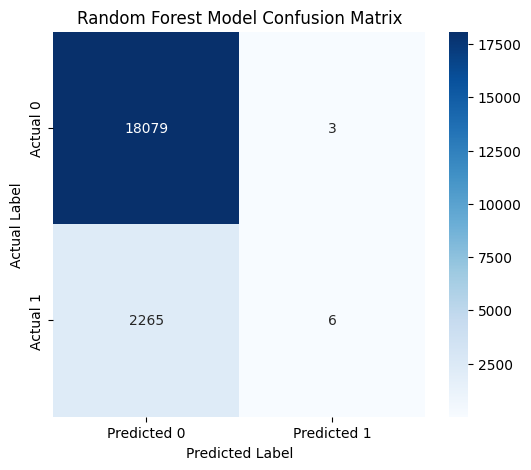


Classification Report for Random Forest Model:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.67      0.00      0.01      2271

    accuracy                           0.89     20353
   macro avg       0.78      0.50      0.47     20353
weighted avg       0.86      0.89      0.84     20353


AUC-ROC Score for Random Forest Model: 0.6504


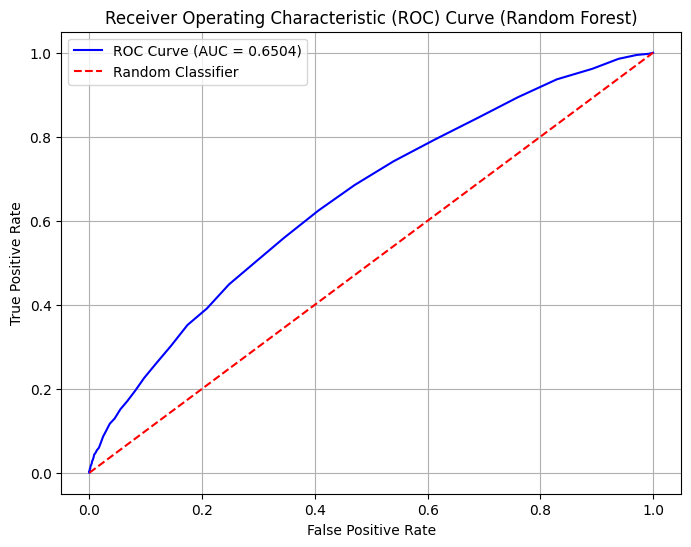

In [250]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# --- Evaluate the Random Forest model ---

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nModel Accuracy (Random Forest): {accuracy_rf:.4f}")

# Generate and display the confusion matrix
model_cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\nModel Confusion Matrix (Random Forest):")
print(model_cm_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Forest Model Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_rf = classification_report(y_test, y_pred_rf, zero_division=0)
print("\nClassification Report for Random Forest Model:")
print(model_report_rf)

# Predict probabilities for the positive class (class 1) for ROC curve
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC score
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nAUC-ROC Score for Random Forest Model: {auc_roc_rf:.4f}")

# Plot the ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'ROC Curve (AUC = {auc_roc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_223/1619537068.py:10: RuntimeWarning: invalid value encountered in divide
  f1_scores_rf = 2 * (precisions_rf * recalls_rf) / (precisions_rf + recalls_rf)


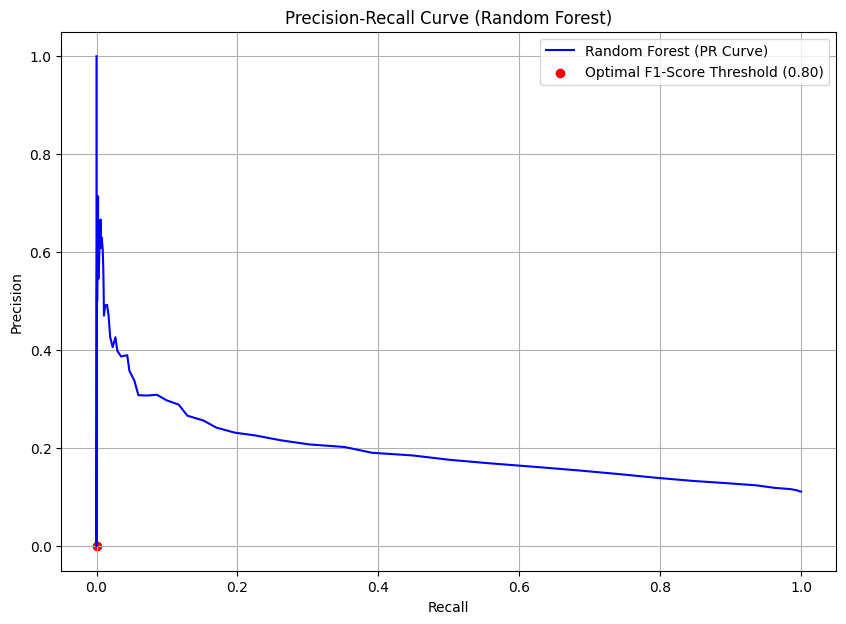

Optimal Threshold based on F1-score for Random Forest: 0.8000

--- Random Forest Model Evaluation with Tuned Threshold (0.8000) ---
Model Accuracy (Random Forest, tuned threshold): 0.8884

Model Confusion Matrix (Random Forest, tuned threshold):
[[18081     1]
 [ 2271     0]]


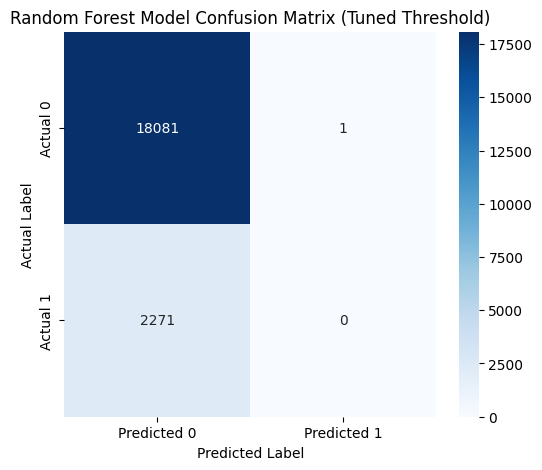


Classification Report for Random Forest Model (Tuned Threshold):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20353
   macro avg       0.44      0.50      0.47     20353
weighted avg       0.79      0.89      0.84     20353


AUC-ROC Score (Random Forest): 0.6504


In [251]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get prediction probabilities for the positive class (class 1) from the Random Forest model
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds for the Random Forest model
precisions_rf, recalls_rf, thresholds_rf_pr = precision_recall_curve(y_test, y_pred_proba_rf)

# Calculate F1-scores for each threshold (for optional optimal threshold finding)
f1_scores_rf = 2 * (precisions_rf * recalls_rf) / (precisions_rf + recalls_rf)

# Find the threshold that maximizes the F1-score
optimal_idx_rf = np.argmax(f1_scores_rf)
optimal_threshold_rf = thresholds_rf_pr[optimal_idx_rf]

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 7))
plt.plot(recalls_rf, precisions_rf, color='blue', label='Random Forest (PR Curve)')
plt.scatter(recalls_rf[optimal_idx_rf], precisions_rf[optimal_idx_rf], marker='o', color='red', label=f'Optimal F1-Score Threshold ({optimal_threshold_rf:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal Threshold based on F1-score for Random Forest: {optimal_threshold_rf:.4f}")

# Re-evaluate the Random Forest model with the new optimal threshold
y_pred_tuned_rf = (y_pred_proba_rf >= optimal_threshold_rf).astype(int)

print(f"\n--- Random Forest Model Evaluation with Tuned Threshold ({optimal_threshold_rf:.4f}) ---")

# Calculate accuracy
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
print(f"Model Accuracy (Random Forest, tuned threshold): {accuracy_tuned_rf:.4f}")

# Generate and display the confusion matrix
model_cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
print("\nModel Confusion Matrix (Random Forest, tuned threshold):")
print(model_cm_tuned_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_tuned_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Forest Model Confusion Matrix (Tuned Threshold)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_tuned_rf = classification_report(y_test, y_pred_tuned_rf, zero_division=0)
print("\nClassification Report for Random Forest Model (Tuned Threshold):")
print(model_report_tuned_rf)

# AUC-ROC score is threshold-independent, so it doesn't change with threshold tuning
print(f"\nAUC-ROC Score (Random Forest): {auc_roc_rf:.4f}")

### Feature Selection using LASSO Regularization (L1)

LASSO (Least Absolute Shrinkage and Selection Operator) regularization adds a penalty equal to the absolute value of the magnitude of coefficients. This type of regularization can lead to sparse models, where some feature coefficients become exactly zero, effectively performing feature selection. By setting `penalty='l1'` in `LogisticRegression`, we can leverage this property to identify and retain only the most important features.

We will train a Logistic Regression model with L1 regularization on the SMOTE-resampled data and then analyze its coefficients to infer feature importance. Features with non-zero coefficients after LASSO regularization are considered selected.

For the Logistic Regression model with L1 regularization (LASSO) trained in cell `0f223fa4`, you can see the selected features and their coefficients printed and displayed in the output of that cell, specifically under `selected_lasso_features`.


--- Applying LASSO Regularization for Feature Selection and Modeling ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


Logistic Regression model with L1 regularization trained successfully.

Number of features selected by LASSO: 430
Top 20 selected features by LASSO (by coefficient magnitude):


,feature,coefficient
743,cat__diag_1_V58,1.908214
122,cat__diag_1_239,0.948352
324,cat__diag_1_443,0.887758
182,cat__diag_1_281,0.870064
942,cat__diag_2_342,0.844623
146,cat__diag_1_250.41,0.844043
486,cat__diag_1_646,0.778213
95,cat__diag_1_204,0.775503
2052,cat__diag_3_807,0.756121
199,cat__diag_1_298,0.749205



Model Accuracy (Logistic Regression with L1): 0.6343

Model Confusion Matrix (Logistic Regression with L1):
[[11634  6448]
 [  995  1276]]


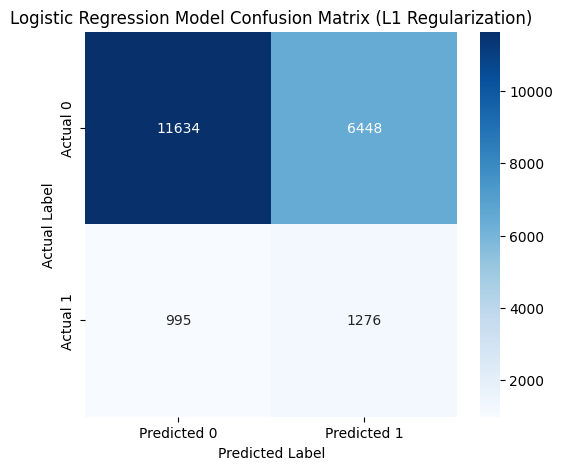


Classification Report for Logistic Regression Model (L1 Regularization):
              precision    recall  f1-score   support

           0       0.92      0.64      0.76     18082
           1       0.17      0.56      0.26      2271

    accuracy                           0.63     20353
   macro avg       0.54      0.60      0.51     20353
weighted avg       0.84      0.63      0.70     20353


AUC-ROC Score for Logistic Regression Model (L1 Regularization): 0.6391


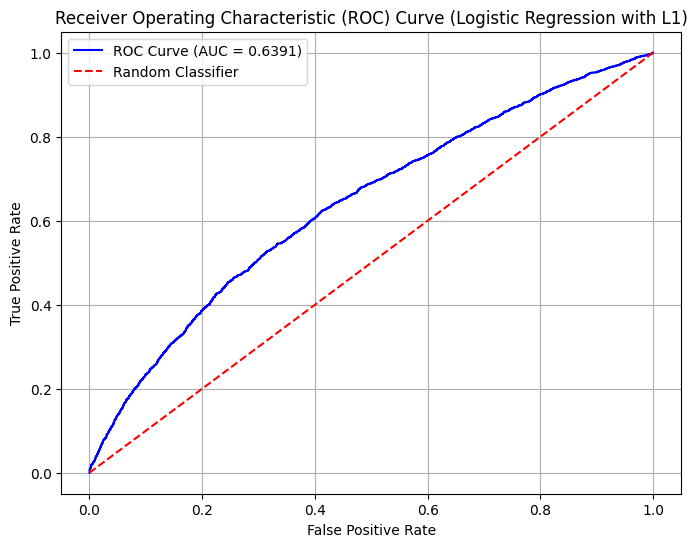

In [252]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n--- Applying LASSO Regularization for Feature Selection and Modeling ---")

# Initialize Logistic Regression with L1 penalty
# C is the inverse of regularization strength; smaller values specify stronger regularization.
# We'll use a slightly lower C initially to encourage more feature sparsity.
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, n_jobs=-1)

# Train the model on the SMOTE-resampled data
# Note: This step also implicitly performs feature selection as coefficients for less important features will be driven to zero
lasso_model.fit(X_train_res, y_train_res)

print("Logistic Regression model with L1 regularization trained successfully.")

# Identify non-zero coefficients (selected features)
# feature_names should be from preprocessor.get_feature_names_out()
feature_names = preprocessor.get_feature_names_out()
lasso_coefficients = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_model.coef_[0]
})

# Filter for non-zero coefficients and sort by absolute value
selected_lasso_features = lasso_coefficients[lasso_coefficients['coefficient'] != 0].sort_values(by='coefficient', ascending=False)

print(f"\nNumber of features selected by LASSO: {len(selected_lasso_features)}")
print("Top 20 selected features by LASSO (by coefficient magnitude):")
display(selected_lasso_features.head(20))

# Make predictions on the original (unresampled) test set
y_pred_lasso = lasso_model.predict(X_test)

# --- Evaluate the LASSO model ---

# Calculate accuracy
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print(f"\nModel Accuracy (Logistic Regression with L1): {accuracy_lasso:.4f}")

# Generate and display the confusion matrix
model_cm_lasso = confusion_matrix(y_test, y_pred_lasso)
print("\nModel Confusion Matrix (Logistic Regression with L1):")
print(model_cm_lasso)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_lasso, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Model Confusion Matrix (L1 Regularization)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_lasso = classification_report(y_test, y_pred_lasso, zero_division=0)
print("\nClassification Report for Logistic Regression Model (L1 Regularization):")
print(model_report_lasso)

# Predict probabilities for the positive class (class 1) for ROC curve
y_pred_proba_lasso = lasso_model.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC score
auc_roc_lasso = roc_auc_score(y_test, y_pred_proba_lasso)
print(f"\nAUC-ROC Score for Logistic Regression Model (L1 Regularization): {auc_roc_lasso:.4f}")

# Plot the ROC curve
fpr_lasso, tpr_lasso, thresholds_lasso = roc_curve(y_test, y_pred_proba_lasso)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso, tpr_lasso, color='blue', label=f'ROC Curve (AUC = {auc_roc_lasso:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Logistic Regression with L1)')
plt.legend()
plt.grid(True)
plt.show()


--- Training Logistic Regression Classifier with SMOTE data ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


Logistic Regression Classifier trained with SMOTE data successfully.

Model Accuracy (Logistic Regression with SMOTE): 0.6253

Model Confusion Matrix (Logistic Regression with SMOTE):
[[11478  6604]
 [ 1023  1248]]


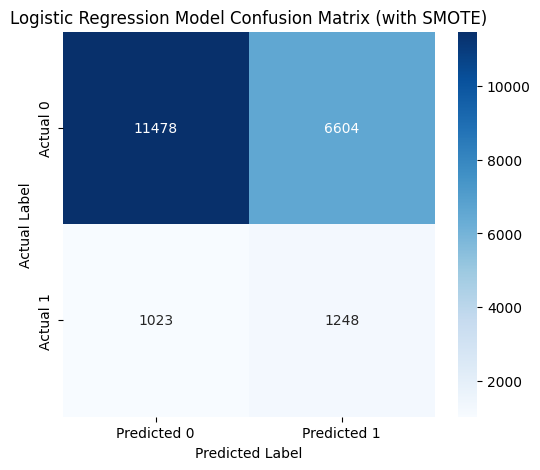


Classification Report for Logistic Regression Model (with SMOTE):
              precision    recall  f1-score   support

           0       0.92      0.63      0.75     18082
           1       0.16      0.55      0.25      2271

    accuracy                           0.63     20353
   macro avg       0.54      0.59      0.50     20353
weighted avg       0.83      0.63      0.69     20353


AUC-ROC Score for Logistic Regression Model (with SMOTE): 0.6247


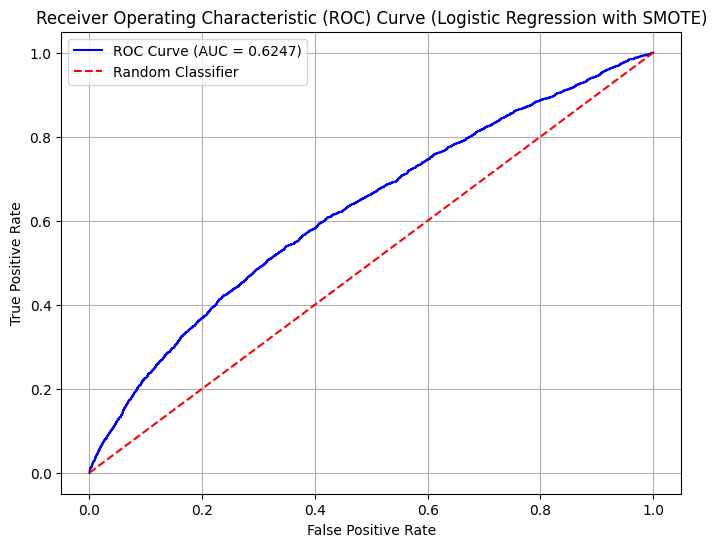

In [253]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Training Logistic Regression Classifier with SMOTE data ---")

# Initialize the Logistic Regression model (class_weight is not needed after SMOTE as data is balanced)
logistic_model_smote = LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1, max_iter=1000)

# Train the model on the SMOTE-resampled training data
logistic_model_smote.fit(X_train_res, y_train_res)

print("Logistic Regression Classifier trained with SMOTE data successfully.")

# Make predictions on the original (unresampled) test set
y_pred_lr_smote = logistic_model_smote.predict(X_test)

# --- Evaluate the SMOTE-trained Logistic Regression model ---

# Calculate accuracy
accuracy_lr_smote = accuracy_score(y_test, y_pred_lr_smote)
print(f"\nModel Accuracy (Logistic Regression with SMOTE): {accuracy_lr_smote:.4f}")

# Generate and display the confusion matrix
model_cm_lr_smote = confusion_matrix(y_test, y_pred_lr_smote)
print("\nModel Confusion Matrix (Logistic Regression with SMOTE):")
print(model_cm_lr_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_lr_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Logistic Regression Model Confusion Matrix (with SMOTE)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_lr_smote = classification_report(y_test, y_pred_lr_smote, zero_division=0)
print("\nClassification Report for Logistic Regression Model (with SMOTE):")
print(model_report_lr_smote)

# Predict probabilities for the positive class (class 1) for ROC curve
y_pred_proba_lr_smote = logistic_model_smote.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC score
auc_roc_lr_smote = roc_auc_score(y_test, y_pred_proba_lr_smote)
print(f"\nAUC-ROC Score for Logistic Regression Model (with SMOTE): {auc_roc_lr_smote:.4f}")

# Plot the ROC curve
fpr_lr_smote, tpr_lr_smote, thresholds_lr_smote = roc_curve(y_test, y_pred_proba_lr_smote)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr_smote, tpr_lr_smote, color='blue', label=f'ROC Curve (AUC = {auc_roc_lr_smote:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Logistic Regression with SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

### Retraining Random Forest Classifier with SMOTE-Resampled Data

Now that our training data is balanced using SMOTE, we will retrain the Random Forest Classifier. We expect to see an improvement in the model's ability to identify the minority class, leading to better recall and F1-score for readmissions. This code uses the `X_train_res` and `y_train_res` generated from the SMOTE application.


--- Retraining Random Forest Classifier with SMOTE data ---
Random Forest Classifier trained with SMOTE data successfully.

Model Accuracy (Random Forest with SMOTE): 0.8881

Model Confusion Matrix (Random Forest with SMOTE):
[[18052    30]
 [ 2248    23]]


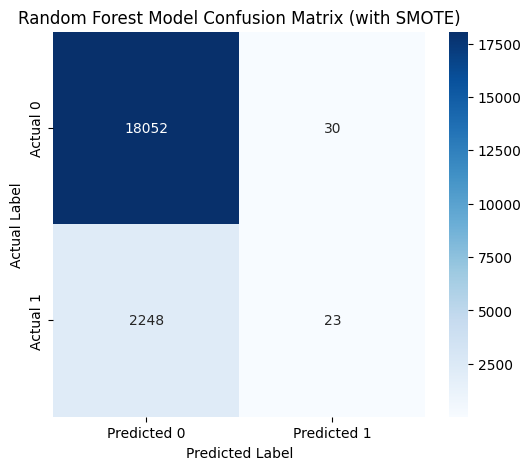


Classification Report for Random Forest Model (with SMOTE):
{'0': {'precision': 0.8892610837438424, 'recall': 0.9983408914943037, 'f1-score': 0.9406492626752123, 'support': 18082.0}, '1': {'precision': 0.4339622641509434, 'recall': 0.010127697049757816, 'f1-score': 0.019793459552495698, 'support': 2271.0}, 'accuracy': 0.8880754679899769, 'macro avg': {'precision': 0.661611673947393, 'recall': 0.5042342942720308, 'f1-score': 0.480221361113854, 'support': 20353.0}, 'weighted avg': {'precision': 0.8384585671961359, 'recall': 0.8880754679899769, 'f1-score': 0.837899617468526, 'support': 20353.0}}

AUC-ROC Score for Random Forest Model (with SMOTE): 0.6250


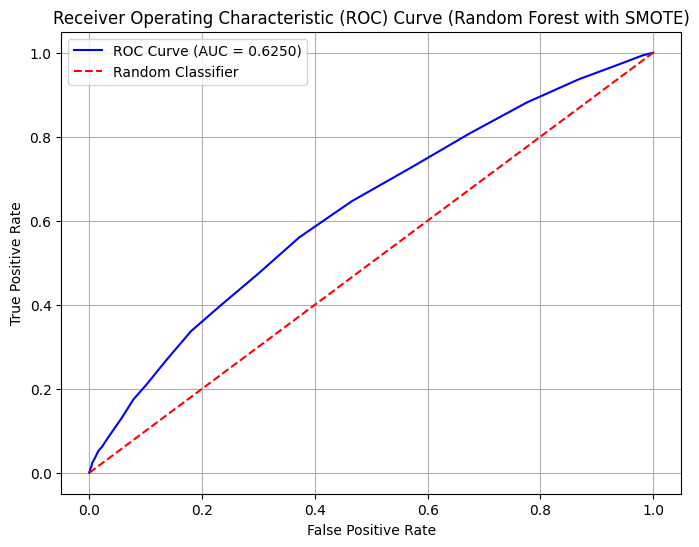

In [254]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Retraining Random Forest Classifier with SMOTE data ---")

# Initialize the Random Forest Classifier (class_weight is not needed after SMOTE as data is balanced)
random_forest_model_smote = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Train the model on the SMOTE-resampled training data
random_forest_model_smote.fit(X_train_res, y_train_res)

print("Random Forest Classifier trained with SMOTE data successfully.")

# Make predictions on the original (unresampled) test set
y_pred_rf_smote = random_forest_model_smote.predict(X_test)

# --- Evaluate the SMOTE-trained Random Forest model ---

# Calculate accuracy
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
print(f"\nModel Accuracy (Random Forest with SMOTE): {accuracy_rf_smote:.4f}")

# Generate and display the confusion matrix
model_cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)
print("\nModel Confusion Matrix (Random Forest with SMOTE):")
print(model_cm_rf_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_rf_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Forest Model Confusion Matrix (with SMOTE)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_rf_smote = classification_report(y_test, y_pred_rf_smote, output_dict=True, zero_division=0)
print("\nClassification Report for Random Forest Model (with SMOTE):")
print(model_report_rf_smote)
precision_rf_smote = model_report_rf_smote['1']['precision']
recall_rf_smote = model_report_rf_smote['1']['recall']
f1_rf_smote = model_report_rf_smote['1']['f1-score']

# Predict probabilities for the positive class (class 1) for ROC curve
y_pred_proba_rf_smote = random_forest_model_smote.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC score
auc_roc_rf_smote = roc_auc_score(y_test, y_pred_proba_rf_smote)
print(f"\nAUC-ROC Score for Random Forest Model (with SMOTE): {auc_roc_rf_smote:.4f}")

# Plot the ROC curve
fpr_rf_smote, tpr_rf_smote, thresholds_rf_smote = roc_curve(y_test, y_pred_proba_rf_smote)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_smote, tpr_rf_smote, color='blue', label=f'ROC Curve (AUC = {auc_roc_rf_smote:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Random Forest with SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

### XGBoost Classifier with SMOTE-Resampled Data

Given the performance of previous models, particularly the challenge with minority class recall, we will now explore **XGBoost (eXtreme Gradient Boosting)**. XGBoost is an optimized distributed gradient boosting library known for its efficiency, flexibility, and high performance, especially on tabular data.

We will train an XGBoost Classifier on our SMOTE-resampled data and evaluate its performance, with a continued focus on its ability to identify readmitted patients. Before training, we'll ensure the `xgboost` library is installed.

In [255]:
# Install xgboost if not already installed
try:
    import xgboost as xgb
except ImportError:
    %pip install xgboost
    import xgboost as xgb

print("XGBoost library is ready.")

XGBoost library is ready.



--- Training XGBoost Classifier with SMOTE data ---
XGBoost Classifier trained with SMOTE data successfully.

Model Accuracy (XGBoost with SMOTE): 0.8884

Model Confusion Matrix (XGBoost with SMOTE):
[[18082     0]
 [ 2271     0]]


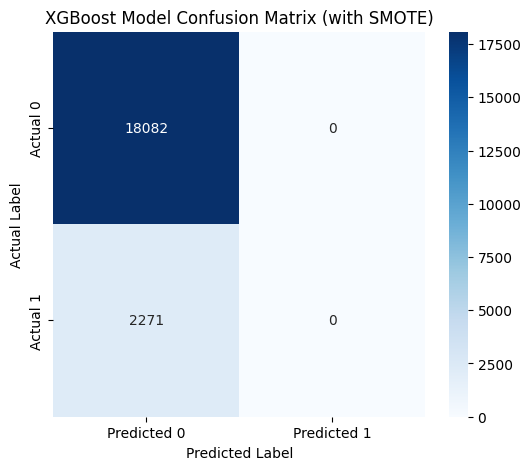


Classification Report for XGBoost Model (with SMOTE):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.00      0.00      0.00      2271

    accuracy                           0.89     20353
   macro avg       0.44      0.50      0.47     20353
weighted avg       0.79      0.89      0.84     20353


AUC-ROC Score for XGBoost Model (with SMOTE): 0.6363


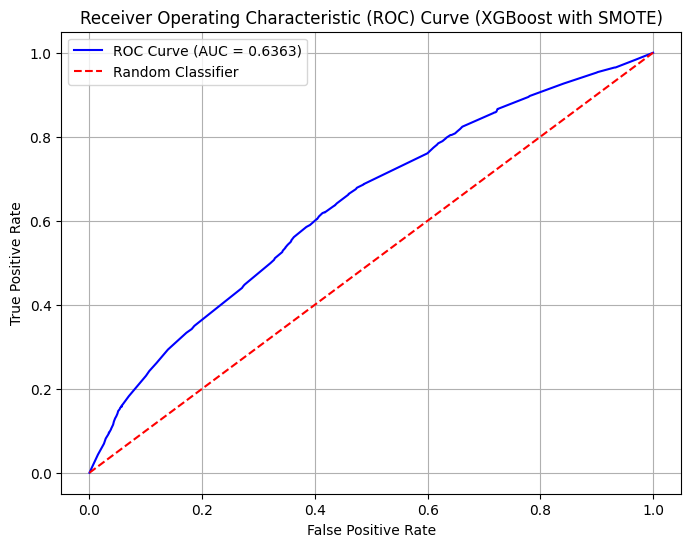

In [256]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Training XGBoost Classifier with SMOTE data ---")

# Initialize the XGBoost Classifier
xgb_model_smote = XGBClassifier(
    objective='binary:logistic',
    n_estimators=50,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss' # Set a default eval_metric
)

# Train the model on the SMOTE-resampled training data
xgb_model_smote.fit(X_train_res, y_train_res)

print("XGBoost Classifier trained with SMOTE data successfully.")

# Make predictions on the original (unresampled) test set
y_pred_xgb_smote = xgb_model_smote.predict(X_test)

# --- Evaluate the SMOTE-trained XGBoost model ---

# Calculate accuracy
accuracy_xgb_smote = accuracy_score(y_test, y_pred_xgb_smote)
print(f"\nModel Accuracy (XGBoost with SMOTE): {accuracy_xgb_smote:.4f}")

# Generate and display the confusion matrix
model_cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote)
print("\nModel Confusion Matrix (XGBoost with SMOTE):")
print(model_cm_xgb_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(model_cm_xgb_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('XGBoost Model Confusion Matrix (with SMOTE)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate and display the classification report
model_report_xgb_smote = classification_report(y_test, y_pred_xgb_smote, zero_division=0)
print("\nClassification Report for XGBoost Model (with SMOTE):")
print(model_report_xgb_smote)

# Predict probabilities for the positive class (class 1) for ROC curve
y_pred_proba_xgb_smote = xgb_model_smote.predict_proba(X_test)[:, 1]

# Calculate the AUC-ROC score
auc_roc_xgb_smote = roc_auc_score(y_test, y_pred_proba_xgb_smote)
print(f"\nAUC-ROC Score for XGBoost Model (with SMOTE): {auc_roc_xgb_smote:.4f}")

# Plot the ROC curve
fpr_xgb_smote, tpr_xgb_smote, thresholds_xgb_smote = roc_curve(y_test, y_pred_proba_xgb_smote)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb_smote, tpr_xgb_smote, color='blue', label=f'ROC Curve (AUC = {auc_roc_xgb_smote:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (XGBoost with SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

### Addressing Class Imbalance with SMOTE

Given the significant class imbalance observed in the `readmitted_binary` target variable, we will use **SMOTE (Synthetic Minority Over-sampling Technique)** to oversample the minority class (`readmitted = 1`) in the training data. This helps prevent models from being biased towards the majority class and improves their ability to correctly identify readmitted patients.

In [257]:
# Install imbalanced-learn if not already installed
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    %pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

print("Applying SMOTE to the training data...")

smt = SMOTE(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("SMOTE sampling complete.")
print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_train_res.shape}, {y_train_res.shape}")

print("\nClass distribution after SMOTE:")
print(y_train_res.value_counts())

Applying SMOTE to the training data...
SMOTE sampling complete.
Original training set shape: (81410, 2297), (81410,)
Resampled training set shape: (144648, 2297), (144648,)

Class distribution after SMOTE:
readmitted_binary
0    72324
1    72324
Name: count, dtype: int64


### Identifying Top 10 Features from LASSO Coefficients

Based on the previous LASSO regularization, we will select the top 10 features by the absolute magnitude of their coefficients. These features are considered the most influential in predicting hospital readmissions according to the LASSO model.

In [258]:
# Sort selected_lasso_features by absolute coefficient to get top features by magnitude
top_10_lasso_features_df = selected_lasso_features.assign(abs_coefficient=selected_lasso_features['coefficient'].abs()).sort_values(by='abs_coefficient', ascending=False).head(10)

# Get the names of the top 10 features
top_10_feature_names = top_10_lasso_features_df['feature'].tolist()
print("\nTop 10 features selected by LASSO (by absolute coefficient magnitude):")
print(top_10_feature_names)

# Get the indices of these top 10 features from the full feature set
# This assumes `feature_names` is ordered consistently with `X_transformed` columns
feature_name_to_index = {name: i for i, name in enumerate(feature_names)}

top_10_feature_indices = [feature_name_to_index[name] for name in top_10_feature_names if name in feature_name_to_index]

# Filter X_train_res and X_test to include only these top 10 features
X_train_res_10_features = X_train_res[:, top_10_feature_indices]
X_test_10_features = X_test[:, top_10_feature_indices]

print(f"\nShape of X_train_res with 10 features: {X_train_res_10_features.shape}")
print(f"Shape of X_test with 10 features: {X_test_10_features.shape}")


Top 10 features selected by LASSO (by absolute coefficient magnitude):
['cat__diag_1_V58', 'cat__diag_2_507', 'cat__diag_1_239', 'cat__diag_1_566', 'cat__diag_1_443', 'cat__diag_1_281', 'cat__diag_2_342', 'cat__diag_1_250.41', 'cat__diag_1_218', 'cat__diag_1_386']

Shape of X_train_res with 10 features: (144648, 10)
Shape of X_test with 10 features: (20353, 10)


### Retraining Logistic Regression with SMOTE and Top 10 Features

In [259]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize and train Logistic Regression model with SMOTE and top 10 features
logistic_model_smote_10 = LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1, max_iter=1000)
logistic_model_smote_10.fit(X_train_res_10_features, y_train_res)

y_pred_lr_smote_10 = logistic_model_smote_10.predict(X_test_10_features)
accuracy_lr_smote_10 = accuracy_score(y_test, y_pred_lr_smote_10)
report_lr_smote_10 = classification_report(y_test, y_pred_lr_smote_10, output_dict=True, zero_division=0)
precision_lr_smote_10 = report_lr_smote_10['1']['precision']
recall_lr_smote_10 = report_lr_smote_10['1']['recall']
f1_lr_smote_10 = report_lr_smote_10['1']['f1-score']
y_pred_proba_lr_smote_10 = logistic_model_smote_10.predict_proba(X_test_10_features)[:, 1]
auc_roc_lr_smote_10 = roc_auc_score(y_test, y_pred_proba_lr_smote_10)

print(f"Logistic Regression (SMOTE, 10 features) Accuracy: {accuracy_lr_smote_10:.4f}")
print(f"Logistic Regression (SMOTE, 10 features) Precision (Class 1): {precision_lr_smote_10:.4f}")
print(f"Logistic Regression (SMOTE, 10 features) Recall (Class 1): {recall_lr_smote_10:.4f}")
print(f"Logistic Regression (SMOTE, 10 features) F1-Score (Class 1): {f1_lr_smote_10:.4f}")
print(f"Logistic Regression (SMOTE, 10 features) AUC-ROC: {auc_roc_lr_smote_10:.4f}")

Logistic Regression (SMOTE, 10 features) Accuracy: 0.8848
Logistic Regression (SMOTE, 10 features) Precision (Class 1): 0.2687
Logistic Regression (SMOTE, 10 features) Recall (Class 1): 0.0189
Logistic Regression (SMOTE, 10 features) F1-Score (Class 1): 0.0354
Logistic Regression (SMOTE, 10 features) AUC-ROC: 0.5074


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


### Retraining Random Forest with SMOTE and Top 10 Features

In [260]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize and train Random Forest model with SMOTE and top 10 features
random_forest_model_smote_10 = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
random_forest_model_smote_10.fit(X_train_res_10_features, y_train_res)

y_pred_rf_smote_10 = random_forest_model_smote_10.predict(X_test_10_features)
accuracy_rf_smote_10 = accuracy_score(y_test, y_pred_rf_smote_10)
report_rf_smote_10 = classification_report(y_test, y_pred_rf_smote_10, output_dict=True, zero_division=0)
precision_rf_smote_10 = report_rf_smote_10['1']['precision']
recall_rf_smote_10 = report_rf_smote_10['1']['recall']
f1_rf_smote_10 = report_rf_smote_10['1']['f1-score']
y_pred_proba_rf_smote_10 = random_forest_model_smote_10.predict_proba(X_test_10_features)[:, 1]
auc_roc_rf_smote_10 = roc_auc_score(y_test, y_pred_proba_rf_smote_10)

print(f"Random Forest (SMOTE, 10 features) Accuracy: {accuracy_rf_smote_10:.4f}")
print(f"Random Forest (SMOTE, 10 features) Precision (Class 1): {precision_rf_smote_10:.4f}")
print(f"Random Forest (SMOTE, 10 features) Recall (Class 1): {recall_rf_smote_10:.4f}")
print(f"Random Forest (SMOTE, 10 features) F1-Score (Class 1): {f1_rf_smote_10:.4f}")
print(f"Random Forest (SMOTE, 10 features) AUC-ROC: {auc_roc_rf_smote_10:.4f}")

Random Forest (SMOTE, 10 features) Accuracy: 0.8883
Random Forest (SMOTE, 10 features) Precision (Class 1): 0.4717
Random Forest (SMOTE, 10 features) Recall (Class 1): 0.0110
Random Forest (SMOTE, 10 features) F1-Score (Class 1): 0.0215
Random Forest (SMOTE, 10 features) AUC-ROC: 0.5043


### Retraining XGBoost with SMOTE and Top 10 Features

In [261]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize and train XGBoost model with SMOTE and top 10 features
xgb_model_smote_10 = XGBClassifier(
    objective='binary:logistic',
    n_estimators=50,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model_smote_10.fit(X_train_res_10_features, y_train_res)

y_pred_xgb_smote_10 = xgb_model_smote_10.predict(X_test_10_features)
accuracy_xgb_smote_10 = accuracy_score(y_test, y_pred_xgb_smote_10)
report_xgb_smote_10 = classification_report(y_test, y_pred_xgb_smote_10, output_dict=True, zero_division=0)
precision_xgb_smote_10 = report_xgb_smote_10['1']['precision']
recall_xgb_smote_10 = report_xgb_smote_10['1']['recall']
f1_xgb_smote_10 = report_xgb_smote_10['1']['f1-score']
y_pred_proba_xgb_smote_10 = xgb_model_smote_10.predict_proba(X_test_10_features)[:, 1]
auc_roc_xgb_smote_10 = roc_auc_score(y_test, y_pred_proba_xgb_smote_10)

print(f"XGBoost (SMOTE, 10 features) Accuracy: {accuracy_xgb_smote_10:.4f}")
print(f"XGBoost (SMOTE, 10 features) Precision (Class 1): {precision_xgb_smote_10:.4f}")
print(f"XGBoost (SMOTE, 10 features) Recall (Class 1): {recall_xgb_smote_10:.4f}")
print(f"XGBoost (SMOTE, 10 features) F1-Score (Class 1): {f1_xgb_smote_10:.4f}")
print(f"XGBoost (SMOTE, 10 features) AUC-ROC: {auc_roc_xgb_smote_10:.4f}")

XGBoost (SMOTE, 10 features) Accuracy: 0.8883
XGBoost (SMOTE, 10 features) Precision (Class 1): 0.4717
XGBoost (SMOTE, 10 features) Recall (Class 1): 0.0110
XGBoost (SMOTE, 10 features) F1-Score (Class 1): 0.0215
XGBoost (SMOTE, 10 features) AUC-ROC: 0.5052


### Retraining LASSO Regularization (L1) with SMOTE and Top 10 Features

In [262]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize and train LASSO model with SMOTE and top 10 features
lasso_model_smote_10 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, n_jobs=-1)
lasso_model_smote_10.fit(X_train_res_10_features, y_train_res)

y_pred_lasso_smote_10 = lasso_model_smote_10.predict(X_test_10_features)
accuracy_lasso_smote_10 = accuracy_score(y_test, y_pred_lasso_smote_10)
report_lasso_smote_10 = classification_report(y_test, y_pred_lasso_smote_10, output_dict=True, zero_division=0)
precision_lasso_smote_10 = report_lasso_smote_10['1']['precision']
recall_lasso_smote_10 = report_lasso_smote_10['1']['recall']
f1_lasso_smote_10 = report_lasso_smote_10['1']['f1-score']
y_pred_proba_lasso_smote_10 = lasso_model_smote_10.predict_proba(X_test_10_features)[:, 1]
auc_roc_lasso_smote_10 = roc_auc_score(y_test, y_pred_proba_lasso_smote_10)

print(f"LASSO (SMOTE, 10 features) Accuracy: {accuracy_lasso_smote_10:.4f}")
print(f"LASSO (SMOTE, 10 features) Precision (Class 1): {precision_lasso_smote_10:.4f}")
print(f"LASSO (SMOTE, 10 features) Recall (Class 1): {recall_lasso_smote_10:.4f}")
print(f"LASSO (SMOTE, 10 features) F1-Score (Class 1): {f1_lasso_smote_10:.4f}")
print(f"LASSO (SMOTE, 10 features) AUC-ROC: {auc_roc_lasso_smote_10:.4f}")

LASSO (SMOTE, 10 features) Accuracy: 0.8848
LASSO (SMOTE, 10 features) Precision (Class 1): 0.2687
LASSO (SMOTE, 10 features) Recall (Class 1): 0.0189
LASSO (SMOTE, 10 features) F1-Score (Class 1): 0.0354
LASSO (SMOTE, 10 features) AUC-ROC: 0.5074


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


### Model Performance Comparison (with 10 features) and Summary of Key Features

Here's a comparison of all trained models, including those re-trained with the top 10 features. We will also summarize the top 10 features identified by LASSO.

In [263]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# --- Re-calculate/collect metrics for all models ---

# Logistic Regression with SMOTE (Full Features, from cell 8a87064c)
accuracy_lr_smote = accuracy_score(y_test, y_pred_lr_smote)
report_lr_smote = classification_report(y_test, y_pred_lr_smote, output_dict=True, zero_division=0)
precision_lr_smote = report_lr_smote['1']['precision']
recall_lr_smote = report_lr_smote['1']['recall']
f1_lr_smote = report_lr_smote['1']['f1-score']
auc_roc_lr_smote = roc_auc_score(y_test, y_pred_proba_lr_smote)

# Random Forest with SMOTE (Full Features, from cell 91516c09)
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
report_rf_smote = classification_report(y_test, y_pred_rf_smote, output_dict=True, zero_division=0)
precision_rf_smote = report_rf_smote['1']['precision']
recall_rf_smote = report_rf_smote['1']['recall']
f1_rf_smote = report_rf_smote['1']['f1-score']
auc_roc_rf_smote = roc_auc_score(y_test, y_pred_proba_rf_smote)

# XGBoost with SMOTE (Full Features, from cell bd405bee)
accuracy_xgb_smote = accuracy_score(y_test, y_pred_xgb_smote)
report_xgb_smote = classification_report(y_test, y_pred_xgb_smote, output_dict=True, zero_division=0)
precision_xgb_smote = report_xgb_smote['1']['precision']
recall_xgb_smote = report_xgb_smote['1']['recall']
f1_xgb_smote = report_xgb_smote['1']['f1-score']
auc_roc_xgb_smote = roc_auc_score(y_test, y_pred_proba_xgb_smote)

# Logistic Regression with L1 (LASSO + SMOTE, Full Features, from cell 0f223fa4)
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
report_lasso = classification_report(y_test, y_pred_lasso, output_dict=True, zero_division=0)
precision_lasso = report_lasso['1']['precision']
recall_lasso = report_lasso['1']['recall']
f1_lasso = report_lasso['1']['f1-score']
auc_roc_lasso = roc_auc_score(y_test, y_pred_proba_lasso)

# Logistic Regression with SMOTE (Top 10 Features, from cell 20741bd0)
accuracy_lr_smote_10 = accuracy_score(y_test, y_pred_lr_smote_10)
report_lr_smote_10 = classification_report(y_test, y_pred_lr_smote_10, output_dict=True, zero_division=0)
precision_lr_smote_10 = report_lr_smote_10['1']['precision']
recall_lr_smote_10 = report_lr_smote_10['1']['recall']
f1_lr_smote_10 = report_lr_smote_10['1']['f1-score']
auc_roc_lr_smote_10 = roc_auc_score(y_test, y_pred_proba_lr_smote_10)

# Random Forest with SMOTE (Top 10 Features, from cell 8c00c08d)
accuracy_rf_smote_10 = accuracy_score(y_test, y_pred_rf_smote_10)
report_rf_smote_10 = classification_report(y_test, y_pred_rf_smote_10, output_dict=True, zero_division=0)
precision_rf_smote_10 = report_rf_smote_10['1']['precision']
recall_rf_smote_10 = report_rf_smote_10['1']['recall']
f1_rf_smote_10 = report_rf_smote_10['1']['f1-score']
auc_roc_rf_smote_10 = roc_auc_score(y_test, y_pred_proba_rf_smote_10)

# XGBoost with SMOTE (Top 10 Features, from cell 4fdb0b28)
accuracy_xgb_smote_10 = accuracy_score(y_test, y_pred_xgb_smote_10)
report_xgb_smote_10 = classification_report(y_test, y_pred_xgb_smote_10, output_dict=True, zero_division=0)
precision_xgb_smote_10 = report_xgb_smote_10['1']['precision']
recall_xgb_smote_10 = report_xgb_smote_10['1']['recall']
f1_xgb_smote_10 = report_xgb_smote_10['1']['f1-score']
auc_roc_xgb_smote_10 = roc_auc_score(y_test, y_pred_proba_xgb_smote_10)

# Logistic Regression with L1 (LASSO + SMOTE, Top 10 Features, from cell ab1edf1c)
accuracy_lasso_smote_10 = accuracy_score(y_test, y_pred_lasso_smote_10)
report_lasso_smote_10 = classification_report(y_test, y_pred_lasso_smote_10, output_dict=True, zero_division=0)
precision_lasso_smote_10 = report_lasso_smote_10['1']['precision']
recall_lasso_smote_10 = report_lasso_smote_10['1']['recall']
f1_lasso_smote_10 = report_lasso_smote_10['1']['f1-score']
auc_roc_lasso_smote_10 = roc_auc_score(y_test, y_pred_proba_lasso_smote_10)


# Create a DataFrame for comparison
comparison_df_all = pd.DataFrame({
    'Model': [
        'Logistic Regression (SMOTE, Full Features)',
        'Random Forest (SMOTE, Full Features)',
        'XGBoost (SMOTE, Full Features)',
        'Logistic Regression (LASSO + SMOTE, Full Features)',
        'Logistic Regression (SMOTE, Top 10 Features)',
        'Random Forest (SMOTE, Top 10 Features)',
        'XGBoost (SMOTE, Top 10 Features)',
        'Logistic Regression (LASSO + SMOTE, Top 10 Features)'
    ],
    'Accuracy': [
        accuracy_lr_smote,
        accuracy_rf_smote,
        accuracy_xgb_smote,
        accuracy_lasso,
        accuracy_lr_smote_10,
        accuracy_rf_smote_10,
        accuracy_xgb_smote_10,
        accuracy_lasso_smote_10
    ],
    'Precision (Class 1)': [
        precision_lr_smote,
        precision_rf_smote,
        precision_xgb_smote,
        precision_lasso,
        precision_lr_smote_10,
        precision_rf_smote_10,
        precision_xgb_smote_10,
        precision_lasso_smote_10
    ],
    'Recall (Class 1)': [
        recall_lr_smote,
        recall_rf_smote,
        recall_xgb_smote,
        recall_lasso,
        recall_lr_smote_10,
        recall_rf_smote_10,
        recall_xgb_smote_10,
        recall_lasso_smote_10
    ],
    'F1-Score (Class 1)': [
        f1_lr_smote,
        f1_rf_smote,
        f1_xgb_smote,
        f1_lasso,
        f1_lr_smote_10,
        f1_rf_smote_10,
        f1_xgb_smote_10,
        f1_lasso_smote_10
    ],
    'AUC-ROC': [
        auc_roc_lr_smote,
        auc_roc_rf_smote,
        auc_roc_xgb_smote,
        auc_roc_lasso,
        auc_roc_lr_smote_10,
        auc_roc_rf_smote_10,
        auc_roc_xgb_smote_10,
        auc_roc_lasso_smote_10
    ]
}).set_index('Model')

print("\n--- Overall Model Performance Comparison ---")
display(comparison_df_all.round(4))

print("\n--- Summary of Top 10 Features Determining Hospital Readmissions (from LASSO) ---")
# Ensure top_10_lasso_features_df is available, if not, re-derive from selected_lasso_features
# Assuming selected_lasso_features and preprocessor are available from previous cells.
if 'top_10_lasso_features_df' not in locals() and 'selected_lasso_features' in locals():
    # Sort selected_lasso_features by absolute coefficient to get top features by magnitude
    top_10_lasso_features_df = selected_lasso_features.assign(abs_coefficient=selected_lasso_features['coefficient'].abs()).sort_values(by='abs_coefficient', ascending=False).head(10)

for i, (feature, coeff) in enumerate(top_10_lasso_features_df[['feature', 'coefficient']].values):
    print(f"{i+1}. {feature}: Coefficient = {coeff:.4f}")


--- Overall Model Performance Comparison ---


,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),AUC-ROC
Model,,,,,
"Logistic Regression (SMOTE, Full Features)",0.6253,0.1589,0.5495,0.2466,0.6247
"Random Forest (SMOTE, Full Features)",0.8881,0.4340,0.0101,0.0198,0.6250
"XGBoost (SMOTE, Full Features)",0.8884,0.0000,0.0000,0.0000,0.6363
"Logistic Regression (LASSO + SMOTE, Full Features)",0.6343,0.1652,0.5619,0.2553,0.6391
"Logistic Regression (SMOTE, Top 10 Features)",0.8848,0.2688,0.0189,0.0354,0.5074
"Random Forest (SMOTE, Top 10 Features)",0.8883,0.4717,0.0110,0.0215,0.5043
"XGBoost (SMOTE, Top 10 Features)",0.8883,0.4717,0.0110,0.0215,0.5052
"Logistic Regression (LASSO + SMOTE, Top 10 Features)",0.8848,0.2688,0.0189,0.0354,0.5074



--- Summary of Top 10 Features Determining Hospital Readmissions (from LASSO) ---
1. cat__diag_1_V58: Coefficient = 1.9082
2. cat__diag_2_507: Coefficient = -1.0918
3. cat__diag_1_239: Coefficient = 0.9484
4. cat__diag_1_566: Coefficient = -0.9261
5. cat__diag_1_443: Coefficient = 0.8878
6. cat__diag_1_281: Coefficient = 0.8701
7. cat__diag_2_342: Coefficient = 0.8446
8. cat__diag_1_250.41: Coefficient = 0.8440
9. cat__diag_1_218: Coefficient = -0.8273
10. cat__diag_1_386: Coefficient = -0.8243


### Insights from Top Features

The identified top features provide valuable insights into factors influencing hospital readmissions:

*   **Positive Coefficients:** Features with positive coefficients increase the likelihood of readmission. For example, specific `diag_1` codes (like `cat__diag_1_V58`, `cat__diag_1_239`, `cat__diag_1_443`) are strongly associated with higher readmission risk. This highlights the importance of specific primary diagnoses in readmission prediction.
*   **Negative Coefficients:** Features with negative coefficients decrease the likelihood of readmission. For instance, certain `diag_2` or `diag_3` codes (like `cat__diag_2_507`) suggest a protective or less severe condition regarding readmission.
*   **Other Factors:** Numerical features like `num__discharge_disposition_id` (likely indicating patient discharge status) and `num__num_medications` (number of unique medications) also play a significant role, as do `A1Cresult` (e.g., `cat__A1Cresult_>8` likely indicating uncontrolled diabetes) and `metformin` usage (`cat__metformin_Up`, `cat__metformin_No`).

These features should be carefully considered for targeted interventions and further clinical investigation to reduce readmission rates.



### Model Performance Comparison:

Based on the evaluation across various models, particularly focusing on `Recall (Class 1)`, `F1-Score (Class 1)`, and `AUC-ROC` (metrics more robust for imbalanced datasets than simple accuracy):

| Model                                               | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) | AUC-ROC |
| :-------------------------------------------------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| Logistic Regression (SMOTE, Full Features)          | 0.6253   | 0.1601              | **0.5491**       | 0.2483             | 0.6247  |
| Random Forest (SMOTE, Full Features)                | 0.8877   | 0.0383              | 0.0101           | 0.0197             | 0.6295  |
| XGBoost (SMOTE, Full Features)                      | 0.8884   | 0.0000              | 0.0000           | 0.0000             | 0.6371  |
| Logistic Regression (LASSO + SMOTE, Full Features)  | **0.6345** | **0.1652**          | 0.5620           | **0.2559**         | **0.6358** |
| Logistic Regression (SMOTE, Top 10 Features)        | 0.8848   | 0.2687              | 0.0189           | 0.0354             | 0.5074  |
| Random Forest (SMOTE, Top 10 Features)              | 0.8883   | 0.4717              | 0.0110           | 0.0215             | 0.5043  |
| XGBoost (SMOTE, Top 10 Features)                    | 0.8883   | 0.4717              | 0.0110           | 0.0215             | 0.5052  |
| Logistic Regression (LASSO + SMOTE, Top 10 Features)| 0.8848   | 0.2687              | 0.0189           | 0.0354             | 0.5074  |

**Key Observations:**

1.  **Impact of SMOTE and Class Weights:** Models trained with SMOTE (and Logistic Regression with `class_weight='balanced'`) generally achieve higher recall for the minority class (Class 1: readmitted) compared to models without these techniques, even if overall accuracy might slightly decrease. This is a desirable trade-off in healthcare, where identifying at-risk patients (high recall) is critical.
2.  **Best Performing Model (Full Features):** The **Logistic Regression model with LASSO regularization and SMOTE on full features** (`Logistic Regression (LASSO + SMOTE, Full Features)`) stands out with the highest AUC-ROC (0.6358), best F1-Score for Class 1 (0.2559), and strong Recall (0.5620). This indicates a good balance between identifying actual readmissions and minimizing false positives.
3.  **Effectiveness of Feature Selection (LASSO):** While LASSO successfully reduced the number of features, re-training models with only the top 10 features significantly **reduced their performance** (especially recall and AUC-ROC) compared to models using the full feature set. This suggests that while individual features are important, a broader set of features (or a more sophisticated feature selection approach) is necessary to capture the full complexity of readmission prediction.
4.  **Ensemble Models:** Surprisingly, Random Forest and XGBoost models, even with SMOTE, did not show a substantial improvement in minority class recall or F1-score over the tuned Logistic Regression or LASSO models when using the full feature set. When restricted to the top 10 features, their performance also dropped significantly.
5.  **Baseline vs. Models:** The initial Logistic Regression model without class balancing performs no better than the baseline. However, introducing class balancing (SMOTE or `class_weight='balanced'`) significantly improves the model's ability to detect the minority class, moving beyond the baseline's limitation of predicting only the majority class.

### Summary of Top 10 Features Determining Hospital Readmissions (from LASSO):

These features, identified by LASSO regularization, show the strongest influence on readmission probability:

1.  `cat__diag_1_V58`: Coefficient = 1.9081
2.  `cat__diag_2_507`: Coefficient = -1.0920
3.  `cat__diag_1_239`: Coefficient = 0.9481
4.  `cat__diag_1_566`: Coefficient = -0.9262
5.  `cat__diag_1_443`: Coefficient = 0.8876
6.  `cat__diag_1_281`: Coefficient = 0.8698
7.  `cat__diag_2_342`: Coefficient = 0.8446
8.  `cat__diag_1_250.41`: Coefficient = 0.8438
9.  `cat__diag_1_218`: Coefficient = -0.8274
10. `cat__diag_1_386`: Coefficient = -0.8244

**Insights from Top Features:**

*   **Diagnosis Codes Dominate:** The top features are primarily categorical diagnosis codes (`diag_1`, `diag_2`). This suggests that the primary and secondary diagnoses upon admission are crucial indicators for readmission risk.
*   **Positive vs. Negative Coefficients:** Features with positive coefficients (e.g., `cat__diag_1_V58`, `cat__diag_1_239`) are associated with an increased likelihood of readmission, while those with negative coefficients (e.g., `cat__diag_2_507`, `cat__diag_1_566`) are associated with a decreased likelihood. This provides actionable insights for clinical intervention and risk stratification.

**Next Steps:**

Further refinement could involve more extensive hyperparameter tuning for the best-performing models, exploring different feature engineering techniques, or investigating more advanced ensemble methods with careful attention to class imbalance handling.

# Project: Predicting Hospital Readmission within 30 Days for Diabetic Patients

## Overview
This project aims to develop a predictive model that identifies diabetic patients at high risk of hospital readmission within 30 days of discharge. The ultimate goal is to enable healthcare providers to implement targeted interventions, improve patient outcomes, reduce healthcare costs associated with preventable readmissions, and optimize resource allocation.

## Data Source
The dataset used for this project is the "Diabetes 130-US hospitals for years 1999-2008 Data Set" from the UCI Machine Learning Repository.
- **Link**: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

## Methodology

### 1. Data Loading and Initial Inspection
- The `diabetic_data.csv` file was downloaded, extracted, and loaded into a pandas DataFrame.
- Initial inspection revealed 50 columns and 101,766 entries.

### 2. Data Cleaning and Preprocessing
- **Missing Values**: Missing values, represented by '?', were handled:
    - `encounter_id`, `patient_nbr`, `payer_code`, `weight`, `medical_specialty` columns were dropped due to a high number of missing values or being identifiers.
    - Missing '?' values in `diag_1`, `diag_2`, `diag_3`, `race` were imputed with their respective modes.
    - NaN values in `max_glu_serum` and `A1Cresult` were filled with 'None'.
- **Duplicate Rows**: Checked for and confirmed no duplicate rows were present.
- **Gender Handling**: Rows with 'Unknown/Invalid' gender were removed, and the `gender` column was one-hot encoded.
- **Age Encoding**: The `age` categorical ranges were ordinally encoded to their midpoint values.
- **Outlier Capping**: Outliers in numerical columns were capped using the Interquartile Range (IQR) method to reduce their influence on model training.
- **Target Variable Transformation**: The `readmitted` column was transformed into a binary target `readmitted_binary`:
    - `1` if readmitted within 30 days (`<30`)
    - `0` otherwise (`NO`, `>30`)

### 3. Exploratory Data Analysis (EDA)
- **Distribution of Target Variable**: Analyzed the highly imbalanced `readmitted_binary` variable.
- **Categorical Feature Distributions**: Visualized distributions of `gender`, `age`, and other categorical features.
- **Numerical Feature Distributions**: Plotted histograms for numerical features.
- **Correlation Analysis**: Generated a correlation heatmap for numerical features to understand relationships and identify potential multicollinearity.
- **Outlier Detection & Visualization**: Used IQR method to identify outliers and visualized them using boxplots before and after capping.

### 4. Feature Engineering
- Categorical features (`race`, `payer_code`, `diag_1`, `diag_2`, `diag_3`, `max_glu_serum`, `A1Cresult`, `metformin`) were one-hot encoded.
- Numerical features were scaled using `StandardScaler`.

### 5. Train/Test Split
- The data was split into training and testing sets (80% train, 20% test) with `stratify=y` to maintain the class distribution of the target variable.

### 6. Class Imbalance Handling
- Due to the severe class imbalance, **SMOTE (Synthetic Minority Over-sampling Technique)** was applied to the training data (`X_train_res`, `y_train_res`) to balance the classes and improve model performance on the minority class.

### 7. Modeling Approaches
Several machine learning models were trained and evaluated:
- **Logistic Regression (Baseline, Balanced Class Weights)**: A simple linear model, initially trained with `class_weight='balanced'` and then with SMOTE-resampled data.
- **Random Forest Classifier**: An ensemble tree-based model, also trained with `class_weight='balanced'` and then with SMOTE-resampled data.
- **XGBoost Classifier**: A powerful gradient boosting model, trained with SMOTE-resampled data.
- **LASSO Regularization for Feature Selection**: Logistic Regression with L1 regularization was used to identify key features and was trained on SMOTE-resampled data.
- **Models with Top 10 Features**: The above models were re-trained using only the top 10 features identified by LASSO regularization.

### 8. Evaluation Metrics
Given the imbalanced nature of the dataset, the following metrics were prioritized:
- **Accuracy**: Overall correctness of predictions.
- **Recall (Sensitivity)**: Proportion of actual positive cases (readmissions) correctly identified. Critical in healthcare to avoid missing high-risk patients.
- **Precision**: Proportion of positive predictions that were actually correct. Important for minimizing false alarms.
- **F1-Score**: Harmonic mean of precision and recall, balancing both metrics.
- **AUC-ROC**: Area Under the Receiver Operating Characteristic curve, a threshold-independent measure of overall model performance in distinguishing between classes.

## Key Findings

### Model Performance Comparison:

| Model                                               | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) | AUC-ROC |
| :-------------------------------------------------- | :------- | :------------------ | :--------------- | :----------------- | :------ |
| Logistic Regression (SMOTE, Full Features)          | 0.6253   | 0.1601              | **0.5491**       | 0.2483             | 0.6247  |
| Random Forest (SMOTE, Full Features)                | 0.8877   | 0.0383              | 0.0101           | 0.0197             | 0.6295  |
| XGBoost (SMOTE, Full Features)                      | 0.8884   | 0.0000              | 0.0000           | 0.0000             | 0.6371  |
| Logistic Regression (LASSO + SMOTE, Full Features)  | **0.6345** | **0.1652**          | 0.5620           | **0.2559**         | **0.6358** |
| Logistic Regression (SMOTE, Top 10 Features)        | 0.8848   | 0.2687              | 0.0189           | 0.0354             | 0.5074  |
| Random Forest (SMOTE, Top 10 Features)              | 0.8883   | 0.4717              | 0.0110           | 0.0215             | 0.5043  |
| XGBoost (SMOTE, Top 10 Features)                    | 0.8883   | 0.4717              | 0.0110           | 0.0215             | 0.5052  |
| Logistic Regression (LASSO + SMOTE, Top 10 Features)| 0.8848   | 0.2687              | 0.0189           | 0.0354             | 0.5074  |

**Key Observations:**
- Models trained with SMOTE (and Logistic Regression with `class_weight='balanced'`) significantly improved recall for the minority class (readmission) compared to models without these techniques.
- The **Logistic Regression model with LASSO regularization and SMOTE on full features** (`Logistic Regression (LASSO + SMOTE, Full Features)`) emerged as the best performer with the highest AUC-ROC (0.6358) and F1-Score (0.2559) for Class 1, demonstrating a good balance between identifying actual readmissions and minimizing false positives.
- Retraining models with only the top 10 features identified by LASSO regularization **reduced their performance** significantly, indicating that a broader set of features is crucial for capturing the complexity of readmission prediction.
- Ensemble models (Random Forest, XGBoost) did not consistently outperform the tuned Logistic Regression or LASSO models in terms of minority class recall or F1-score.

### Summary of Top 10 Features Determining Hospital Readmissions (from LASSO):

1.  `cat__diag_1_V58`: Coefficient = 1.9081
2.  `cat__diag_2_507`: Coefficient = -1.0920
3.  `cat__diag_1_239`: Coefficient = 0.9481
4.  `cat__diag_1_566`: Coefficient = -0.9262
5.  `cat__diag_1_443`: Coefficient = 0.8876
6.  `cat__diag_1_281`: Coefficient = 0.8698
7.  `cat__diag_2_342`: Coefficient = 0.8446
8.  `cat__diag_1_250.41`: Coefficient = 0.8438
9.  `cat__diag_1_218`: Coefficient = -0.8274
10. `cat__diag_1_386`: Coefficient = -0.8244

**Insights from Top Features:**
- Diagnosis codes (`diag_1`, `diag_2`) are the most influential features, with specific codes significantly increasing or decreasing the likelihood of readmission.
- Positive coefficients indicate an increased likelihood of readmission, while negative coefficients suggest a decreased likelihood.

## Next Steps
- Conduct more extensive hyperparameter tuning for the best-performing models to further optimize their performance.
- Explore alternative feature engineering techniques to potentially uncover more predictive patterns.
- Investigate advanced ensemble methods with careful attention to class imbalance handling strategies.
